#  Modelo de Regresión para Predicción del Volumen de Tráfico Vehicular


## 1. Introducción

El análisis y predicción del tráfico vehicular representa uno de los desafíos más relevantes en el campo de la ingeniería de transporte y la ciencia de datos aplicada. Con el crecimiento acelerado de las ciudades y el aumento sostenido del parque automotor, comprender los patrones de flujo vehicular se convierte en una necesidad estratégica para la planificación urbana, la gestión de infraestructura vial y la reducción de congestión.

El presente notebook desarrolla un análisis completo de machine learning supervisado, específicamente modelos de , para predecir el volumen de tráfico (`traffic_volume`) a partir de variables meteorológicas, temporales y ambientales. Se implementan y comparan múltiples algoritmos, desde métodos clásicos como Ridge/Lasso hasta técnicas de ensemble como XGBoost y Random Forest.


## 2. Contexto

El tráfico vehicular está influenciado por una combinación compleja de factores: condiciones climáticas (lluvia, niebla, temperatura), variables temporales (hora del día, día de la semana, festivos), y factores ambientales (índice de contaminación, visibilidad). Los modelos predictivos permiten a autoridades viales y sistemas inteligentes de transporte anticipar cuellos de botella y optimizar el flujo.

El análisis se fundamenta en datos similares al dataset público “Metro Interstate Traffic Volume” del UCI Machine Learning Repository, el cual contiene registros horarios del tráfico sobre la Interestatal I-94 en Minneapolis–St Paul, junto con variables climáticas y temporales relevantes.

## 3. Planteamiento del Problema

Las entidades de gestión de tráfico carecen frecuentemente de herramientas predictivas que integren variables meteorológicas y temporales para estimar el volumen vehicular en tiempo real o anticipado. Esto dificulta la toma de decisiones proactivas para mitigar la congestión, especialmente en días festivos, eventos climáticos extremos o en horas pico.

**Pregunta de investigación:** ¿Es posible predecir con precisión el volumen de tráfico vehicular a partir de variables meteorológicas, ambientales y temporales, utilizando modelos de aprendizaje automático supervisado?



## 4. Objetivo General

Desarrollar y evaluar un modelo de regresión basado en aprendizaje automático capaz de predecir el volumen de tráfico vehicular (`traffic_volume`) con alta precisión, utilizando variables meteorológicas, ambientales y temporales derivadas del dataset.



## 5. Objetivos Específicos

1. **Realizar un análisis exploratorio** exhaustivo del dataset para identificar distribuciones, valores atípicos, correlaciones y patrones de comportamiento frente a la variable objetivo.
2. **Preprocesar y transformar** las variables del dataset, incluyendo la extracción de componentes temporales de `date_time` y la codificación de variables categóricas.
3. **Diseñar e implementar un pipeline** de machine learning robusto que estandarice el flujo de preprocesamiento, entrenamiento y evaluación de modelos.
4. **Entrenar y comparar** siete algoritmos de regresión (XGBoost, Random Forest, Árbol de Decisión, KNN, SVM, Ridge y Lasso) mediante métricas estándar de regresión.
5. **Seleccionar y validar el modelo final** con mayor poder predictivo, evaluando su rendimiento mediante pruebas estadísticas y análisis de residuales.



## 6. Justificación

La predicción del volumen de tráfico tiene impacto directo en áreas como la planificación urbana, reducción de emisiones de CO₂, diseño de rutas de transporte público y respuesta de emergencias. Contar con modelos de alta precisión permite:

- **Reducir la congestión** mediante semáforos adaptativos y redireccionamiento vehicular.
- **Optimizar recursos** en mantenimiento vial al identificar períodos de alta demanda.
- **Apoyar decisiones de inversión** en infraestructura basadas en datos.

El uso de múltiples modelos y su comparación sistemática garantiza que la solución adoptada sea la más adecuada para el comportamiento específico del dataset.



## 7. Marco Teórico

### 7.1 Regresión Supervisada
La regresión es una técnica de aprendizaje supervisado que busca aprender una función $f: X \rightarrow y$ donde $y$ es una variable continua. El objetivo es minimizar el error de predicción sobre datos no vistos.

### 7.2 Modelos Implementados

| Modelo | Descripción |
|--------|-------------|
| **XGBoost** | Gradient boosting optimizado; combina múltiples árboles débiles con regularización L1/L2. Alta capacidad predictiva y resistencia al overfitting. |
| **Random Forest** | Ensemble de árboles de decisión con bagging. Robusto ante outliers y ruido. Proporciona importancia de variables. |
| **Árbol de Decisión** | Modelo base interpretable. Particiona el espacio de características de forma jerárquica. Propenso a overfitting sin poda. |
| **KNN** | Predicción basada en los $k$ vecinos más cercanos. Sensible a la escala y dimensionalidad. |
| **SVM (SVR)** | Support Vector Regression; maximiza el margen en un espacio de alta dimensión. Efectivo con datos no lineales mediante kernels. |
| **Ridge** | Regresión lineal con regularización L2. Reduce la varianza penalizando coeficientes grandes. |
| **Lasso** | Regresión lineal con regularización L1. Realiza selección automática de variables al llevar coeficientes a cero. |

### 7.3 Métricas de Evaluación

- **MAE** (Mean Absolute Error): Error promedio en unidades originales.
- **RMSE** (Root Mean Squared Error): Penaliza errores grandes.
- **R²** (Coeficiente de Determinación): Proporción de varianza explicada.
- **MAPE** (Mean Absolute Percentage Error): Error porcentual promedio.



## 8. Configuración e Importación de Librerías

In [1]:
# ── Librerías estándar ──
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, kruskal

# ── Preprocesamiento ──
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ── Modelos ──
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

# ── Métricas ──
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# ── Visualización extra ──
from sklearn.inspection import permutation_importance

# ── Configuración global de visualización ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette('viridis')
SEED = 42
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---

## 9. Carga y Descripción Inicial de los Datos

In [2]:
df = pd.read_csv('Traffic.csv')
# 'None' en is_holiday significa 'no es festivo', no es un valor nulo
df['is_holiday'] = df['is_holiday'].fillna('No Holiday').replace('None', 'No Holiday')
df.head()

,date_time,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
0,2012-10-02 09:00:00,No Holiday,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
1,2012-10-02 10:00:00,No Holiday,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2,2012-10-02 11:00:00,No Holiday,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
3,2012-10-02 12:00:00,No Holiday,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
4,2012-10-02 13:00:00,No Holiday,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [3]:
print('=== Información general del dataset ===')
df.info()
print('\n=== Estadísticas descriptivas ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33750 entries, 0 to 33749
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date_time            33750 non-null  object 
 1   is_holiday           33750 non-null  object 
 2   air_pollution_index  33750 non-null  int64  
 3   humidity             33750 non-null  int64  
 4   wind_speed           33750 non-null  int64  
 5   wind_direction       33750 non-null  int64  
 6   visibility_in_miles  33750 non-null  int64  
 7   dew_point            33750 non-null  int64  
 8   temperature          33750 non-null  float64
 9   rain_p_h             33750 non-null  float64
 10  snow_p_h             33750 non-null  float64
 11  clouds_all           33750 non-null  int64  
 12  weather_type         33750 non-null  object 
 13  weather_description  33750 non-null  object 
 14  traffic_volume       33750 non-null  int64  
d

,count,mean,std,min,25%,50%,75%,max
air_pollution_index,33750.000000,154.841422,83.735515,10.000000,83.000000,155.000000,228.000000,299.000000
humidity,33750.000000,71.209007,16.852248,13.000000,60.000000,72.000000,85.000000,100.000000
wind_speed,33750.000000,3.378193,2.055792,0.000000,2.000000,3.000000,5.000000,16.000000
wind_direction,33750.000000,199.471852,99.841088,0.000000,130.000000,200.000000,290.000000,360.000000
visibility_in_miles,33750.000000,4.989748,2.570021,1.000000,3.000000,5.000000,7.000000,9.000000
dew_point,33750.000000,4.989748,2.570021,1.000000,3.000000,5.000000,7.000000,9.000000
temperature,33750.000000,280.069587,13.415256,0.000000,271.720000,280.150000,290.620000,308.240000
rain_p_h,33750.000000,0.448739,53.526500,0.000000,0.000000,0.000000,0.000000,9831.300000
snow_p_h,33750.000000,0.000318,0.009760,0.000000,0.000000,0.000000,0.000000,0.510000
clouds_all,33750.000000,50.458785,38.871734,0.000000,1.000000,64.000000,90.000000,100.000000


In [4]:
print('=== Valores nulos por columna ===')
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})[nulls > 0]

=== Valores nulos por columna ===


,Nulos,Porcentaje (%)



## 10. ETL — Transformación e Interpretación de Datos

Antes del análisis exploratorio se aplican y documentan todas las transformaciones necesarias para dejar el dataset en condiciones óptimas de análisis y modelado.

### 10.1 Detección y Eliminación de Duplicados

**Transformación:** Se identifican y eliminan filas exactamente duplicadas.

**Interpretación:** Los duplicados sesgan los estadísticos descriptivos y sobrerepresentan ciertos registros durante el entrenamiento. Su eliminación garantiza que cada observación sea única e independiente.

In [5]:
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_dup = n_antes - len(df)
print(f"Registros originales:  {n_antes:,}")
print(f"Duplicados eliminados: {n_dup}")
print(f"Registros resultantes: {len(df):,}")

Registros originales:  33,750
Duplicados eliminados: 0
Registros resultantes: 33,750


### 10.2 Tratamiento de `is_holiday`

 Los registros donde `is_holiday` contiene el string `"None"` o valores nulos se reemplazan por `"No Holiday"` (aplicado en la carga del CSV).

 En este dataset `None` no indica dato faltante, sino que ese momento no corresponde a un festivo. Codificarlo como categoría explícita evita que los modelos lo traten como ausencia de información, y permite que aparezca correctamente en visualizaciones y análisis categóricos.

In [6]:
print("Distribución de is_holiday:")
print(df["is_holiday"].value_counts().to_string())

Distribución de is_holiday:
is_holiday
No Holiday                   33707
Thanksgiving Day                 5
New Years Day                    5
Christmas Day                    5
Veterans Day                     4
Columbus Day                     4
Washingtons Birthday             4
Labor Day                        4
Memorial Day                     3
Independence Day                 3
State Fair                       3
Martin Luther King Jr Day        3


### 10.3 Conversión de `date_time` a tipo `datetime`

**Transformación:** La columna `date_time` se convierte de `object` (string) a `datetime64[ns]`.

**Interpretación:** La conversión es indispensable para extraer componentes temporales con precisión mediante el accessor `.dt`. Sin ella no sería posible obtener hora, día, mes ni año de forma confiable.

In [7]:
df["date_time"] = pd.to_datetime(df["date_time"])
print(f"Tipo actual: {df['date_time'].dtype}")
print(f"\nRango temporal:")
print(f"  Desde: {df['date_time'].min()}")
print(f"  Hasta: {df['date_time'].max()}")
print(f"  Duración: {df['date_time'].max() - df['date_time'].min()}")

Tipo actual: datetime64[ns]

Rango temporal:
  Desde: 2012-10-02 09:00:00
  Hasta: 2017-05-17 23:00:00
  Duración: 1688 days 14:00:00


### 10.4 Extracción de Variables Temporales

**Transformación:** A partir de `date_time` se derivan cuatro variables numéricas: `hour`, `day_of_week`y `month`.

**Interpretación:** El tráfico vehicular exhibe patrones cíclicos marcados. La hora captura picos matutinos y vespertinos; el día de semana diferencia hábiles de fin de semana; el mes refleja estacionalidad anual; el año permite detectar tendencias de largo plazo. Descomponer la fecha en estas unidades hace que la información temporal sea directamente consumible por los modelos.

In [8]:
df["hour"]        = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"]       = df["date_time"].dt.month

print("Variables temporales extraídas:")
print(df[["date_time", "hour", "day_of_week", "month"]].head(8).to_string())

Variables temporales extraídas:
            date_time  hour  day_of_week  month
0 2012-10-02 09:00:00     9            1     10
1 2012-10-02 10:00:00    10            1     10
2 2012-10-02 11:00:00    11            1     10
3 2012-10-02 12:00:00    12            1     10
4 2012-10-02 13:00:00    13            1     10
5 2012-10-02 14:00:00    14            1     10
6 2012-10-02 15:00:00    15            1     10
7 2012-10-02 16:00:00    16            1     10


### 10.5 Codificación Cíclica de `hour` → `hour_sin` / `hour_cos`

**Transformación:** La hora se proyecta sobre el círculo unitario con periodo 24:

- `hour_sin = sin(2π · hour / 24)`
- `hour_cos = cos(2π · hour / 24)`

**Interpretación:** La hora es una variable cíclica: la hora 23 y la hora 0 son consecutivas, pero numéricamente están a 23 unidades de distancia. Representarla como un punto en el círculo unitario (sin, cos) elimina esa discontinuidad artificial y permite que los modelos capturen correctamente la transición noche–madrugada. La variable `hour` original se conserva para visualización.

In [9]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

print("Codificación cíclica (un valor único por hora):")
print(
    df[["hour", "hour_sin", "hour_cos"]]
    .drop_duplicates("hour").sort_values("hour").to_string(index=False)
)

Codificación cíclica (un valor único por hora):
 hour      hour_sin      hour_cos
    0  0.000000e+00  1.000000e+00
    1  2.588190e-01  9.659258e-01
    2  5.000000e-01  8.660254e-01
    3  7.071068e-01  7.071068e-01
    4  8.660254e-01  5.000000e-01
    5  9.659258e-01  2.588190e-01
    6  1.000000e+00  6.123234e-17
    7  9.659258e-01 -2.588190e-01
    8  8.660254e-01 -5.000000e-01
    9  7.071068e-01 -7.071068e-01
   10  5.000000e-01 -8.660254e-01
   11  2.588190e-01 -9.659258e-01
   12  1.224647e-16 -1.000000e+00
   13 -2.588190e-01 -9.659258e-01
   14 -5.000000e-01 -8.660254e-01
   15 -7.071068e-01 -7.071068e-01
   16 -8.660254e-01 -5.000000e-01
   17 -9.659258e-01 -2.588190e-01
   18 -1.000000e+00 -1.836970e-16
   19 -9.659258e-01  2.588190e-01
   20 -8.660254e-01  5.000000e-01
   21 -7.071068e-01  7.071068e-01
   22 -5.000000e-01  8.660254e-01
   23 -2.588190e-01  9.659258e-01


### 10.5.1 Interpretación de la Codificación Cíclica

La transformación sin/cos proyecta cada hora sobre el **círculo unitario** (radio = 1). Ambas componentes deben usarse juntas para representar unívocamente cualquier hora del día:


**¿Cómo los interpretan los modelos ?**
- `hour_cos ≈ +1` → madrugada → el modelo puede predecir: **tráfico bajo**.
- `hour_cos ≈ −1` → mediodía → el modelo puede predecir: **tráfico alto**.
- `hour_sin ≈ +1` → ∼6 AM → **hora pico matutina** (entrada al trabajo).
- `hour_sin ≈ −1` → ∼6 PM → **hora pico vespertina** (salida del trabajo).

**La mayor ventaja es:** la discontinuidad entre hora 23 y hora 0 desaparece. Ambas horas tienen coordenadas casi idénticas (sin ≈ −0.26, cos ≈ 1.00), lo que el modelo interpreta correctamente como horas consecutivas, algo imposible si se usara la hora como número entero (0 y 23 estarían a 23 unidades de distancia).

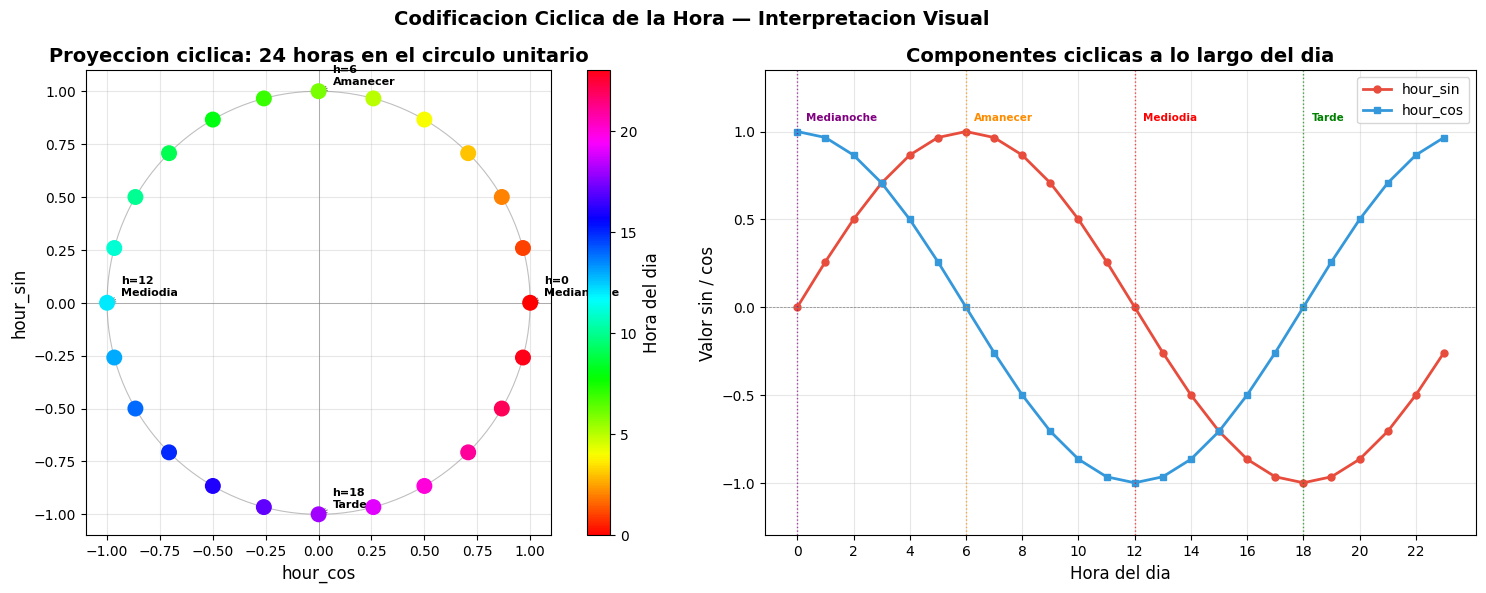

Tabla de referencia — Codificacion ciclica de horas clave:
  Hora    hour_sin    hour_cos
  h= 0:  sin=+0.0000   cos=+1.0000
  h= 3:  sin=+0.7071   cos=+0.7071
  h= 6:  sin=+1.0000   cos=+0.0000
  h= 9:  sin=+0.7071   cos=-0.7071
  h=12:  sin=+0.0000   cos=-1.0000
  h=15:  sin=-0.7071   cos=-0.7071
  h=18:  sin=-1.0000   cos=-0.0000
  h=21:  sin=-0.7071   cos=+0.7071
  h=23:  sin=-0.2588   cos=+0.9659


In [10]:
# ── Visualización: círculo unitario y evolución diaria ──
hours = np.arange(24)
h_sin = np.sin(2 * np.pi * hours / 24)
h_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — Círculo unitario
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linewidth=0.8, alpha=0.5)
sc = ax.scatter(h_cos, h_sin, c=hours, cmap='hsv', s=110, zorder=5)
for h, lbl in [(0, 'h=0\nMedianoche'), (6, 'h=6\nAmanecer'),
               (12, 'h=12\nMediodia'), (18, 'h=18\nTarde')]:
    ax.annotate(lbl, (h_cos[h], h_sin[h]), textcoords='offset points',
                xytext=(10, 5), fontsize=8, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.axhline(0, color='gray', linewidth=0.4)
ax.axvline(0, color='gray', linewidth=0.4)
ax.set_xlabel('hour_cos')
ax.set_ylabel('hour_sin')
ax.set_title('Proyeccion ciclica: 24 horas en el circulo unitario', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Hora del dia')
ax.set_aspect('equal')

# Panel 2 — Evolución a lo largo del día
ax2 = axes[1]
ax2.plot(hours, h_sin, 'o-', color='#e74c3c', label='hour_sin', linewidth=2, markersize=5)
ax2.plot(hours, h_cos, 's-', color='#3498db', label='hour_cos', linewidth=2, markersize=5)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
for h, lbl, col in [(0,'Medianoche','purple'), (6,'Amanecer','darkorange'),
                    (12,'Mediodia','red'), (18,'Tarde','green')]:
    ax2.axvline(h, color=col, linewidth=1, linestyle=':', alpha=0.7)
    ax2.text(h + 0.3, 1.06, lbl, fontsize=7.5, color=col, fontweight='bold')
ax2.set_xlabel('Hora del dia')
ax2.set_ylabel('Valor sin / cos')
ax2.set_title('Componentes ciclicas a lo largo del dia', fontweight='bold')
ax2.set_xticks(hours[::2])
ax2.legend()
ax2.set_ylim(-1.3, 1.35)

plt.suptitle('Codificacion Ciclica de la Hora — Interpretacion Visual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de referencia
print('Tabla de referencia — Codificacion ciclica de horas clave:')
print(f'{"Hora":>6}  {"hour_sin":>10}  {"hour_cos":>10}')
for h in [0, 3, 6, 9, 12, 15, 18, 21, 23]:
    print(f'  h={h:2d}:  sin={h_sin[h]:+.4f}   cos={h_cos[h]:+.4f}')

Transformamos la variable hora usando codificación cíclica con seno y coseno para preservar la naturaleza periódica del tiempo. Esto evita que el modelo interprete incorrectamente horas cercanas como distantes, por ejemplo 23:00 y 00:00.

### 10.6 Verificación Final — Nulos Tras Transformaciones ETL

Se confirma que ninguna columna presenta valores nulos tras el proceso de transformación. Esto garantiza que el análisis exploratorio y el modelado operarán sobre datos completos y consistentes.

In [11]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
resumen = pd.DataFrame({"Nulos": nulls, "Porcentaje (%)": null_pct})[nulls > 0]

if resumen.empty:
    print("Sin valores nulos tras las transformaciones ETL.")
else:
    print("Columnas con nulos pendientes:")
    print(resumen.to_string())

print(f"\nShape final del dataset: {df.shape}")

Sin valores nulos tras las transformaciones ETL.

Shape final del dataset: (33750, 20)



## 11. Análisis Exploratorio de Datos (EDA)

### 11.1 Distribución de la Variable Objetivo

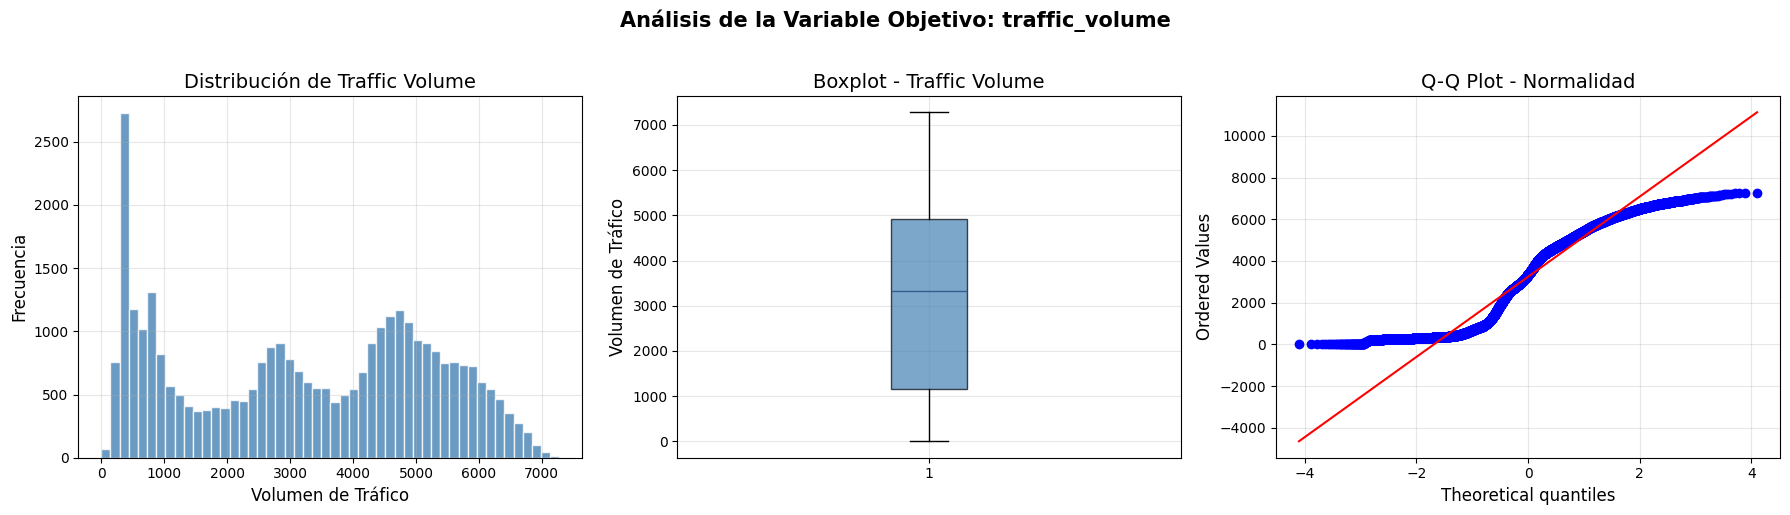

Media:     3240.12
Mediana:   3335.00
Std:       1991.49
Skewness:  -0.071
Kurtosis:  -1.316


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['traffic_volume'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Traffic Volume')
axes[0].set_xlabel('Volumen de Tráfico')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['traffic_volume'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot - Traffic Volume')
axes[1].set_ylabel('Volumen de Tráfico')

# Q-Q plot
stats.probplot(df['traffic_volume'].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot - Normalidad')

plt.suptitle('Análisis de la Variable Objetivo: traffic_volume', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Media:     {df["traffic_volume"].mean():.2f}')
print(f'Mediana:   {df["traffic_volume"].median():.2f}')
print(f'Std:       {df["traffic_volume"].std():.2f}')
print(f'Skewness:  {df["traffic_volume"].skew():.3f}')
print(f'Kurtosis:  {df["traffic_volume"].kurt():.3f}')

El análisis exploratorio de traffic_volume muestra una distribución multimodal y no normal. Aunque la variable presenta una asimetría casi nula, el Q-Q plot evidencia desviaciones importantes respecto a la distribución gaussiana. Además, la dispersión es considerable y la curtosis negativa indica una distribución más plana, posiblemente influenciada por distintos patrones temporales del tráfico.

### 11.2 Test de Normalidad (Shapiro-Wilk)

In [13]:
# Shapiro-Wilk sobre muestra (máx 5000)
sample = df['traffic_volume'].dropna().sample(min(1000, len(df)), random_state=SEED)
stat, p_value = shapiro(sample)
print(f'Shapiro-Wilk Test:')
print(f'  Estadístico W = {stat:.4f}')
print(f'  p-value       = {p_value:.6f}')
if p_value < 0.05:
    print('    La distribución NO es normal (p < 0.05) → Se consideran modelos robustos no paramétricos.')
else:
    print('   No se rechaza normalidad (p >= 0.05)')

Shapiro-Wilk Test:
  Estadístico W = 0.9337
  p-value       = 0.000000
    La distribución NO es normal (p < 0.05) → Se consideran modelos robustos no paramétricos.


###  Variables Temporales y Codificación Cíclica

> Las variables `hour`, `day_of_week`, `month`, `hour_sin` y `hour_cos` fueron generadas en la sección ETL (10.4 y 10.5).

In [14]:
print(df[["date_time", "hour", "hour_sin", "hour_cos", "day_of_week", "month"]]
      .head(8).to_string())

            date_time  hour      hour_sin  hour_cos  day_of_week  month
0 2012-10-02 09:00:00     9  7.071068e-01 -0.707107            1     10
1 2012-10-02 10:00:00    10  5.000000e-01 -0.866025            1     10
2 2012-10-02 11:00:00    11  2.588190e-01 -0.965926            1     10
3 2012-10-02 12:00:00    12  1.224647e-16 -1.000000            1     10
4 2012-10-02 13:00:00    13 -2.588190e-01 -0.965926            1     10
5 2012-10-02 14:00:00    14 -5.000000e-01 -0.866025            1     10
6 2012-10-02 15:00:00    15 -7.071068e-01 -0.707107            1     10
7 2012-10-02 16:00:00    16 -8.660254e-01 -0.500000            1     10


### 11.4 Comportamiento Temporal frente al Target

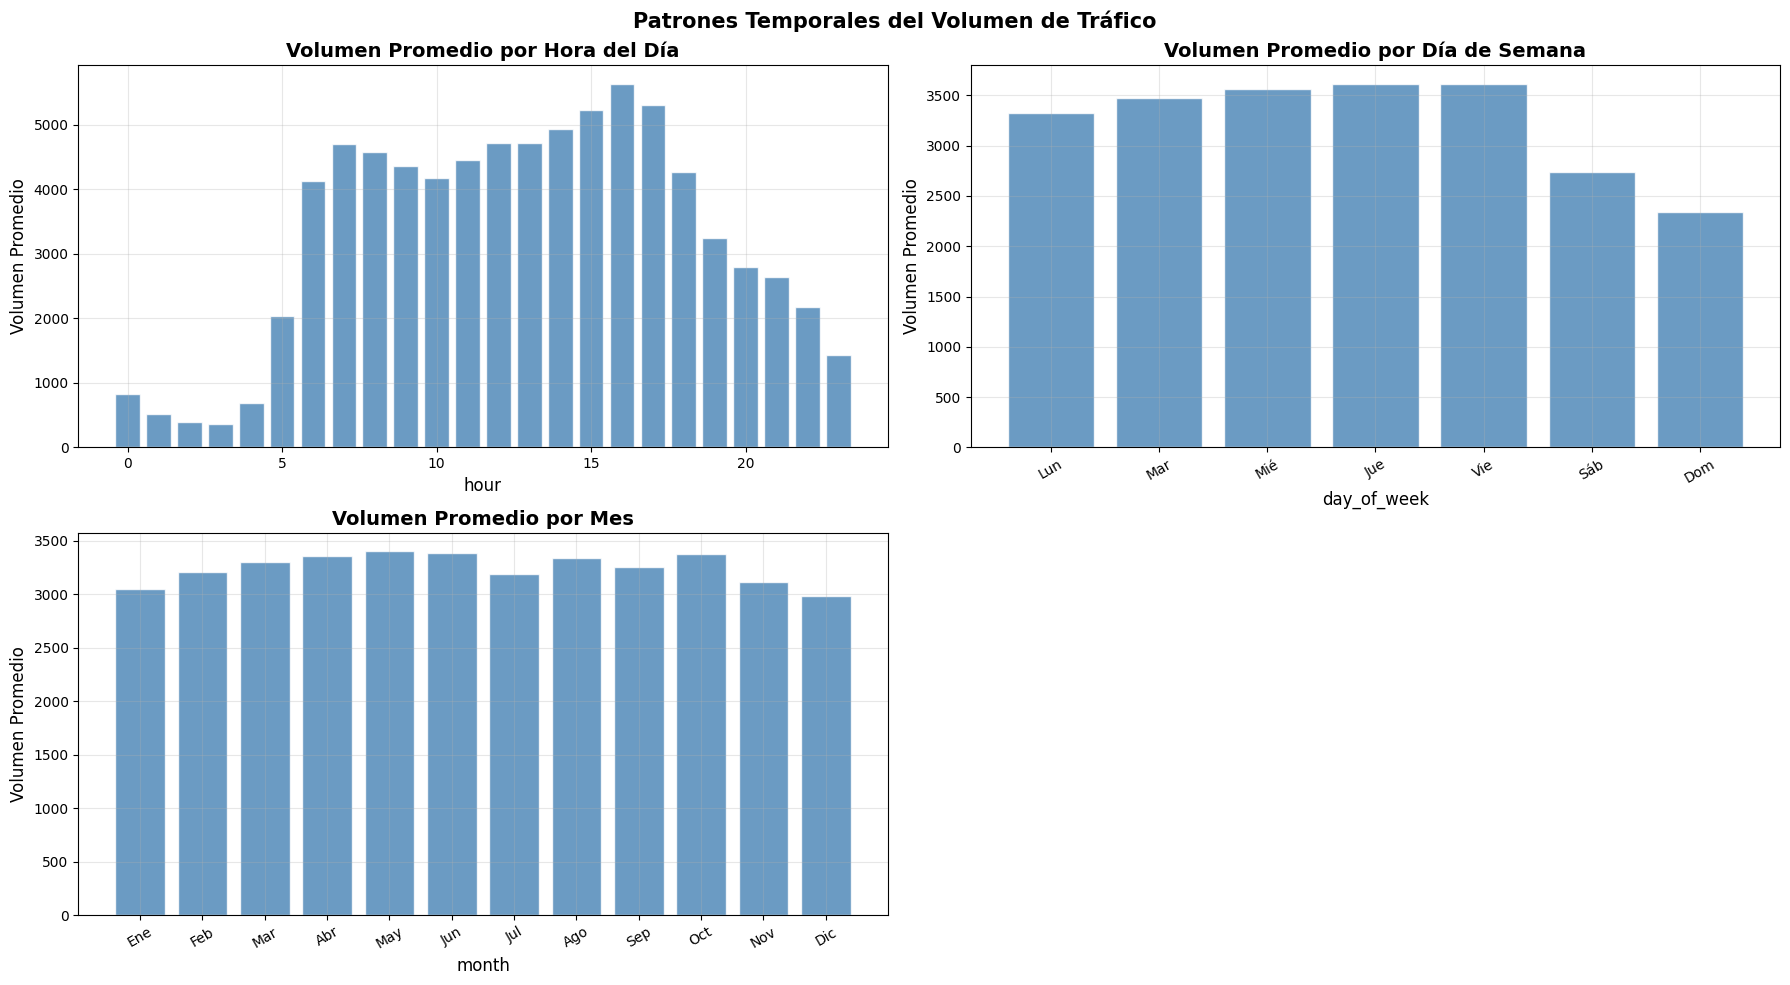

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

for ax, (group_col, title, xticklabels) in zip(
        axes.flatten(),
        [('hour', 'Volumen Promedio por Hora del Día', None),
         ('day_of_week', 'Volumen Promedio por Día de Semana', day_names),
         ('month', 'Volumen Promedio por Mes', month_names)]):

    grp = df.groupby(group_col)['traffic_volume'].mean()

    ax.bar(
        grp.index,
        grp.values,
        color='steelblue',
        alpha=0.8,
        edgecolor='white'
    )

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Volumen Promedio')
    ax.set_xlabel(group_col)

    if xticklabels:
        ax.set_xticks(grp.index)
        ax.set_xticklabels(xticklabels, rotation=30)

# 🔥 eliminar subplot vacío
fig.delaxes(axes[1,1])

plt.suptitle(
    'Patrones Temporales del Volumen de Tráfico',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

El análisis temporal revela patrones claros en el comportamiento del tráfico. El volumen varía significativamente según la hora del día y el día de la semana, mostrando picos durante horarios laborales y reducciones importantes en fines de semana. A nivel mensual, las variaciones son más moderadas, lo que sugiere estabilidad y una estacionalidad limitada.

### 11.5 Correlaciones con el Target (Variables Numéricas)

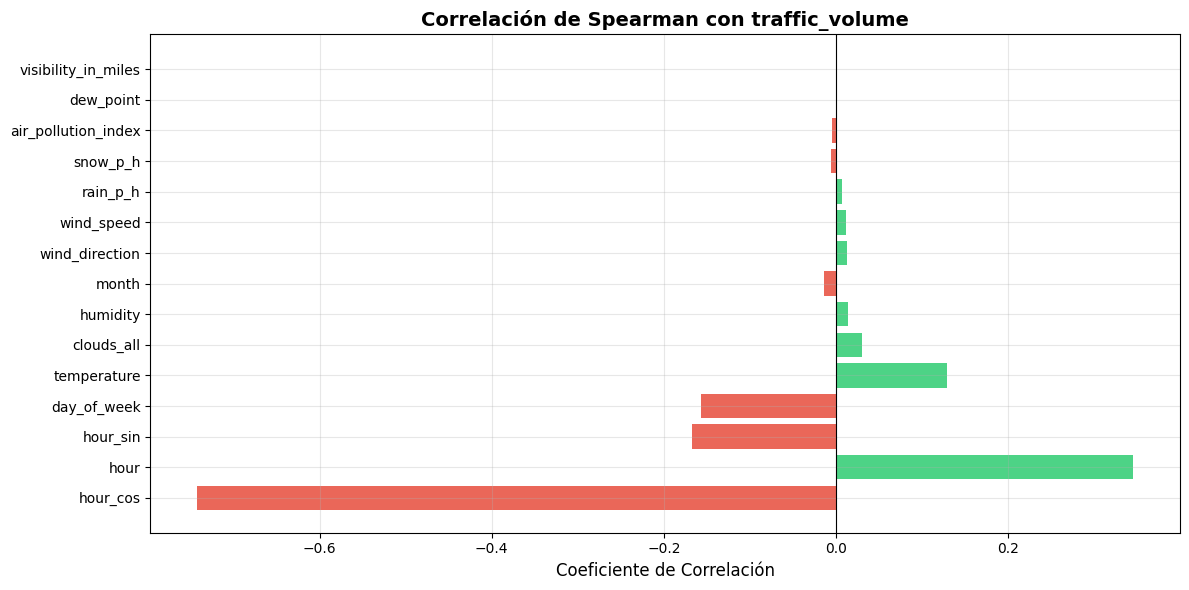


Top 10 correlaciones (absoluto):
hour_cos         -0.742146
hour              0.345265
hour_sin         -0.167263
day_of_week      -0.157115
temperature       0.128484
clouds_all        0.029872
humidity          0.014442
month            -0.013498
wind_direction    0.012469
wind_speed        0.011720


In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = (df[num_cols]
                    .corr(method='spearman')['traffic_volume']
                    .drop('traffic_volume')
                    .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target]

ax.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_title('Correlación de Spearman con traffic_volume', fontweight='bold', fontsize=14)
ax.set_xlabel('Coeficiente de Correlación')

plt.tight_layout()
plt.show()

print('\nTop 10 correlaciones (absoluto):')
print(corr_with_target.head(10).to_string())

El análisis de correlación de Spearman evidencia que las variables temporales son las más influyentes en la predicción del volumen de tráfico, especialmente las variables derivadas de la codificación cíclica de la hora. En contraste, las variables climáticas presentan correlaciones más débiles, sugiriendo un impacto secundario sobre el comportamiento del tráfico.

### 11.6 Mapa de Calor de Correlaciones

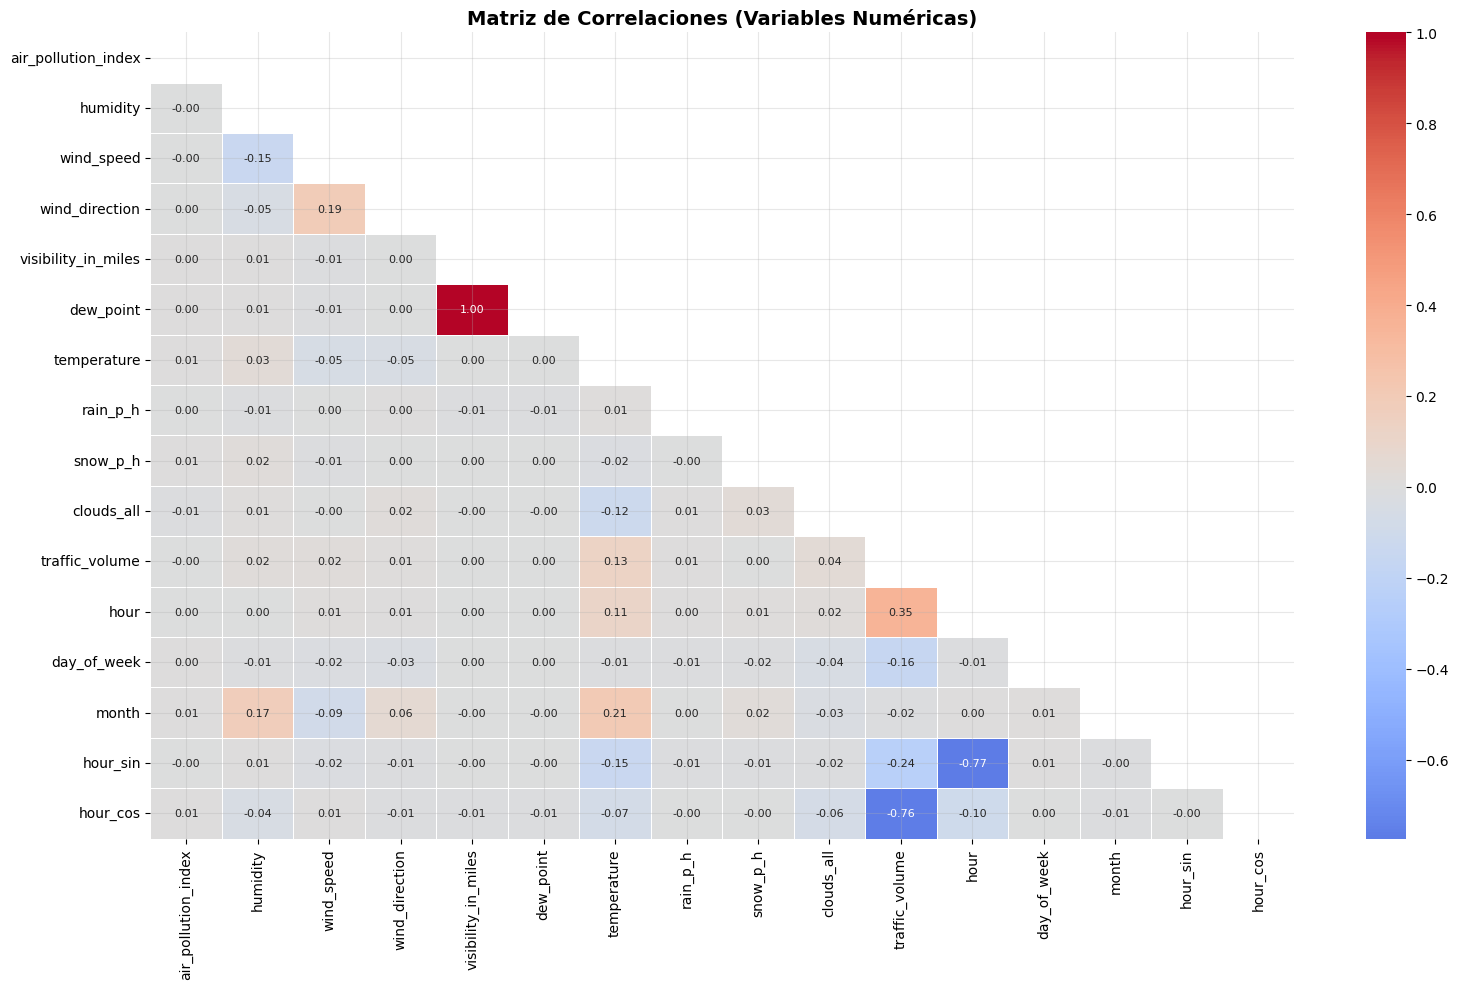

In [17]:
plt.figure(figsize=(16, 10))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlaciones (Variables Numéricas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La matriz de correlaciones evidencia que las variables temporales son las más relacionadas con el volumen de tráfico, especialmente las variables derivadas de la codificación cíclica de la hora. En contraste, las variables climáticas presentan correlaciones débiles. Además, se observa correlación entre variables temporales derivadas, lo cual es esperado debido a su origen común. Debido a la alta multicolinealidad de 1 entre Dew_point y visibility_in_miles, no se va a usar la primera variable para el modelo.

### 11.7 Análisis de Variables Categóricas frente al Target

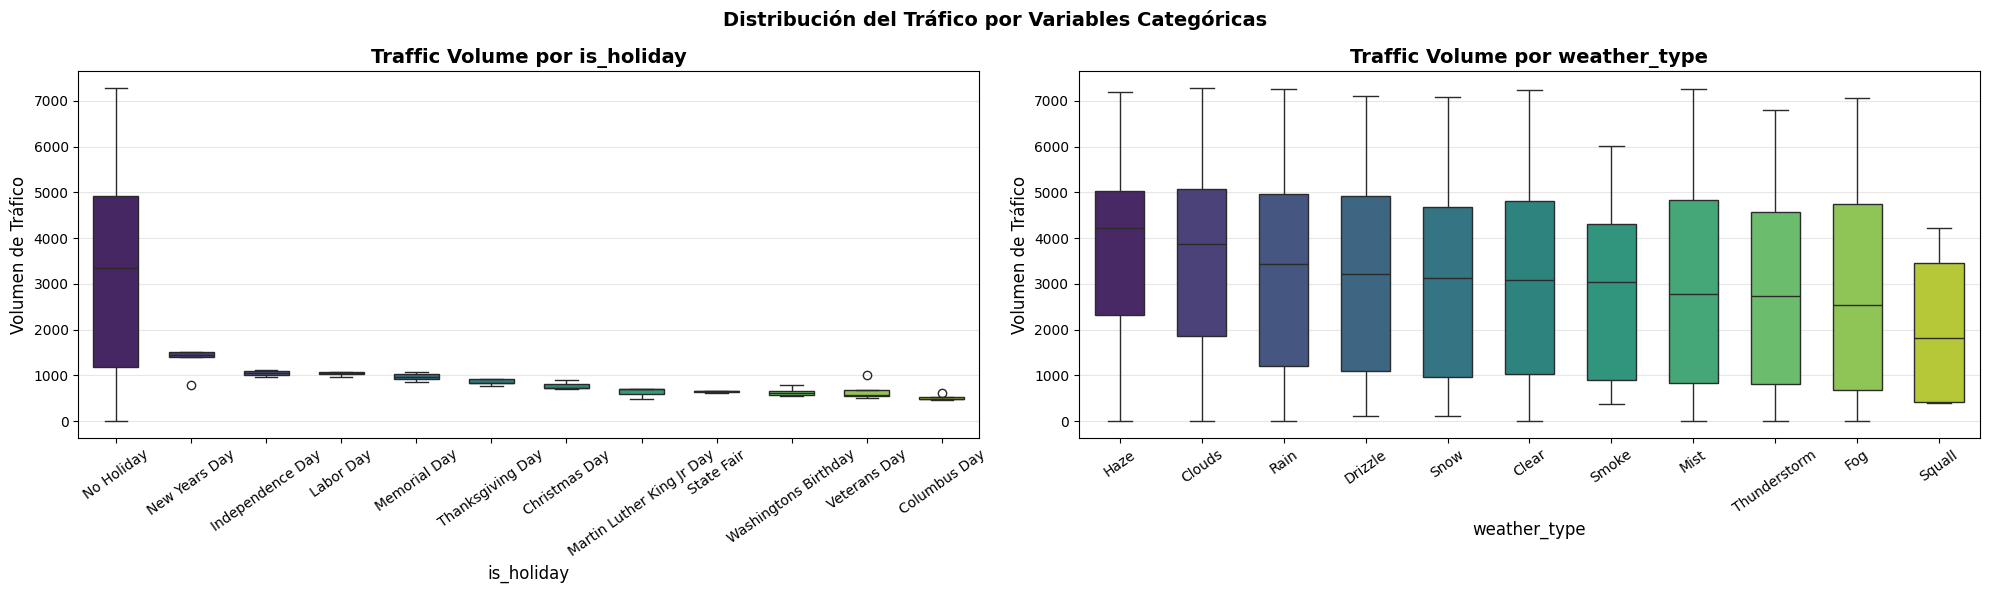

In [18]:
cat_cols = ['is_holiday', 'weather_type']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 6))

for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['traffic_volume'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='traffic_volume', order=order, ax=ax,
                palette='viridis', width=0.6)
    ax.set_title(f'Traffic Volume por {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Volumen de Tráfico')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('Distribución del Tráfico por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis de variables categóricas muestra que los días no festivos concentran mayores volúmenes de tráfico, evidenciando la influencia de las actividades laborales y rutinarias. Asimismo, las condiciones climáticas extremas tienden a reducir el tráfico promedio, aunque su impacto es menos significativo que el observado en las variables temporales.

### 11.8 Test Kruskal-Wallis: Significancia de Variables Categóricas

In [19]:
print('=== Test de Kruskal-Wallis (diferencia de medianas por grupos) ===\n')
for col in cat_cols:
    groups = [df.loc[df[col] == val, 'traffic_volume'].dropna().values
              for val in df[col].unique()]
    groups = [g for g in groups if len(g) > 0]
    stat, p = kruskal(*groups)
    sig = '✅ Significativo' if p < 0.05 else '⚠️ No significativo'
    print(f'{col:<25} H = {stat:.2f}  p = {p:.4f}  → {sig}')

=== Test de Kruskal-Wallis (diferencia de medianas por grupos) ===

is_holiday                H = 50.62  p = 0.0000  → ✅ Significativo
weather_type              H = 433.41  p = 0.0000  → ✅ Significativo


El test no paramétrico de Kruskal-Wallis confirmó diferencias estadísticamente significativas en el volumen de tráfico según festividades y condiciones climáticas. Los resultados sugieren que tanto el tipo de clima como su descripción detallada influyen de manera importante en los patrones de movilidad.

### 11.9 Scatter Plots: Variables Numéricas vs Target

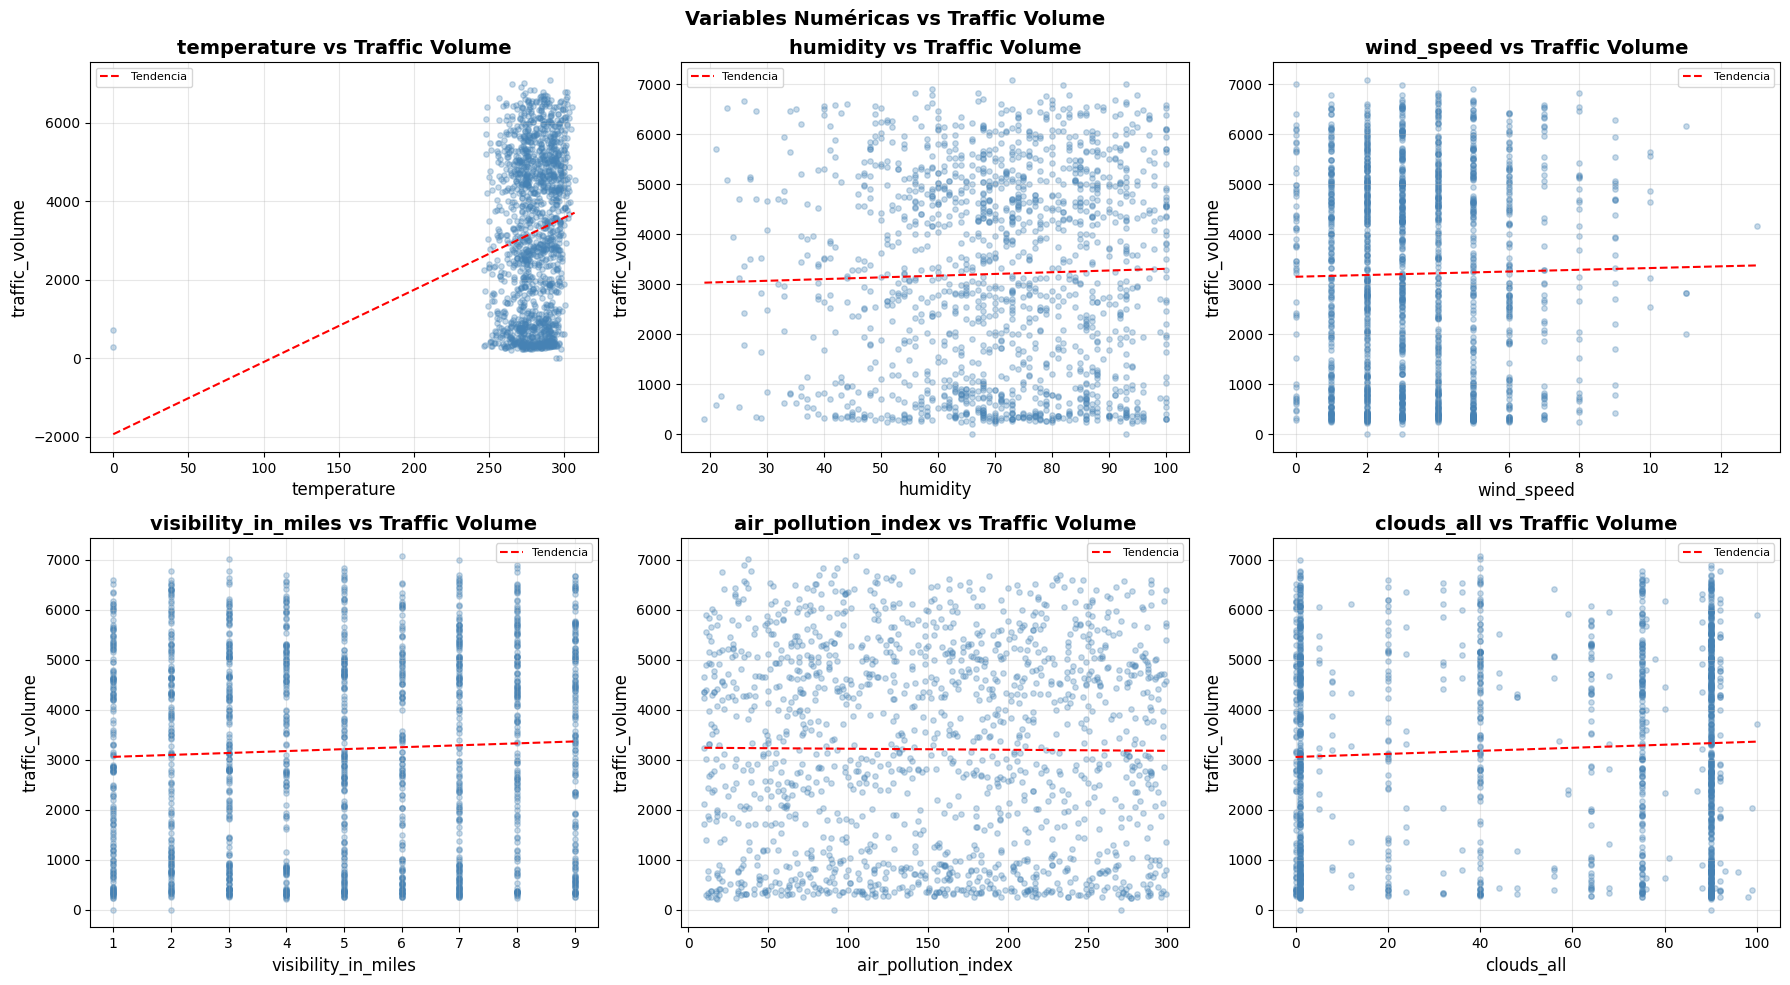

In [20]:
scatter_vars = ['temperature', 'humidity', 'wind_speed', 'visibility_in_miles',
                'air_pollution_index', 'clouds_all']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sample_df = df.sample(min(1500, len(df)), random_state=SEED)

for ax, col in zip(axes.flatten(), scatter_vars):
    ax.scatter(sample_df[col], sample_df['traffic_volume'],
               alpha=0.3, s=15, color='steelblue')
    # Línea de tendencia
    valid = sample_df[[col, 'traffic_volume']].dropna()
    z = np.polyfit(valid[col], valid['traffic_volume'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Tendencia')
    ax.set_xlabel(col)
    ax.set_ylabel('traffic_volume')
    ax.set_title(f'{col} vs Traffic Volume', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Variables Numéricas vs Traffic Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis de dispersión muestra que las variables climáticas presentan relaciones relativamente débiles con el volumen de tráfico. La temperatura es la variable que evidencia la asociación positiva más clara, mientras que humedad, viento, contaminación y nubosidad muestran patrones poco definidos y alta dispersión.”

### 11.10 Detección de Outliers (IQR)

In [21]:
print('=== Detección de Outliers por IQR ===\n')
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Outliers': n_out,
                             'Outliers %': round(n_out/len(df)*100, 2)}

pd.DataFrame(outlier_summary).T.style.background_gradient(subset=['Outliers %'], cmap='YlOrRd')

=== Detección de Outliers por IQR ===



,Q1,Q3,IQR,Outliers,Outliers %
air_pollution_index,83.000000,228.000000,145.000000,0.000000,0.000000
humidity,60.000000,85.000000,25.000000,102.000000,0.300000
wind_speed,2.000000,5.000000,3.000000,207.000000,0.610000
wind_direction,130.000000,290.000000,160.000000,0.000000,0.000000
visibility_in_miles,3.000000,7.000000,4.000000,0.000000,0.000000
dew_point,3.000000,7.000000,4.000000,0.000000,0.000000
temperature,271.720000,290.620000,18.900000,10.000000,0.030000
rain_p_h,0.000000,0.000000,0.000000,2754.000000,8.160000
snow_p_h,0.000000,0.000000,0.000000,63.000000,0.190000
clouds_all,1.000000,90.000000,89.000000,0.000000,0.000000


El análisis de outliers mostró una baja presencia general de valores atípicos en la mayoría de las variables. La variable rain_p_h presentó el mayor porcentaje de outliers, lo cual es coherente con la naturaleza irregular de las precipitaciones. En contraste, la variable objetivo traffic_volume no evidenció valores extremos significativos, indicando estabilidad en el comportamiento del tráfico.

### 15.3 Análisis de Multicolinealidad — VIF (Variance Inflation Factor)

El VIF mide cuánto se infla la varianza de un coeficiente por la correlación entre features. Se calcula sobre el conjunto de entrenamiento.



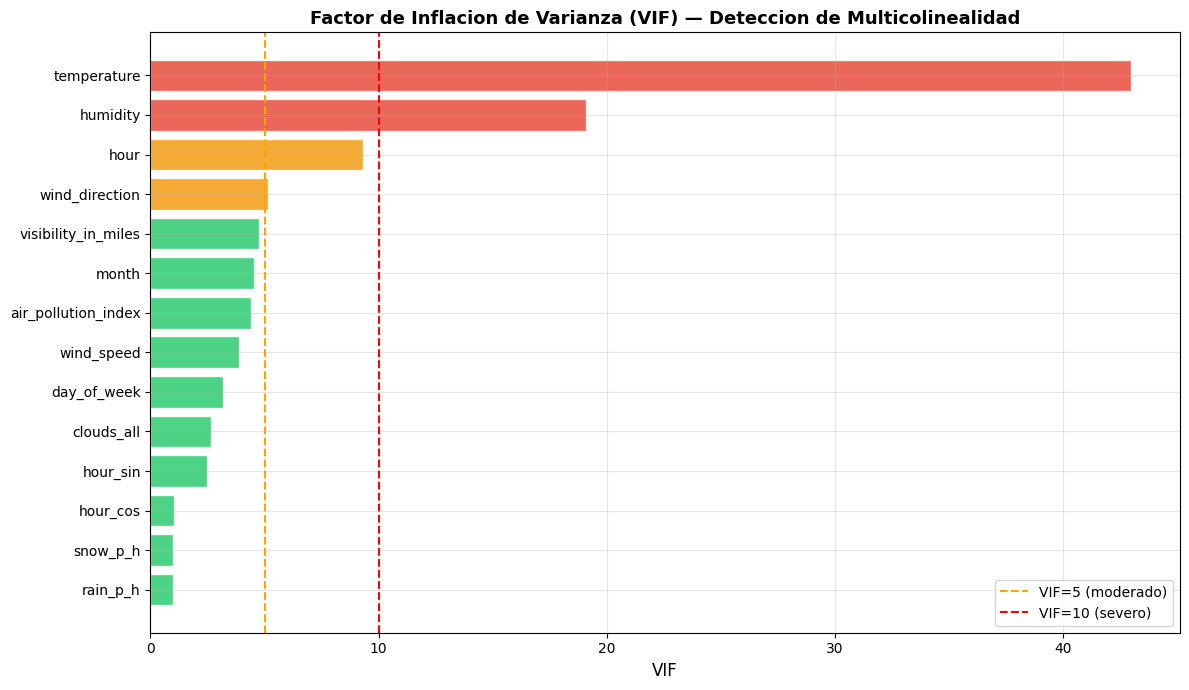

Resultados VIF:
            Feature       VIF
        temperature 42.962291
           humidity 19.081009
               hour  9.305389
     wind_direction  5.159953
visibility_in_miles  4.737402
              month  4.557029
air_pollution_index  4.394149
         wind_speed  3.899779
        day_of_week  3.197924
         clouds_all  2.665115
           hour_sin  2.470298
           hour_cos  1.029217
           snow_p_h  1.003617
           rain_p_h  1.000524

Variables con VIF > 10: 2
    Feature       VIF
temperature 42.962291
   humidity 19.081009


In [22]:
# ── VIF sobre el conjunto de entrenamiento ──
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'statsmodels', '-q'], check=True)
    from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_matrix = df[[c for c in num_cols if c not in ['traffic_volume', 'dew_point']]]
vif_matrix = vif_matrix.reset_index(drop=True).astype(float)
vif_values = pd.DataFrame({
    'Feature': vif_matrix.columns,
    'VIF': [variance_inflation_factor(vif_matrix.values, i)
            for i in range(vif_matrix.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
col_map = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
           for v in vif_values['VIF']]
ax.barh(vif_values['Feature'][::-1], vif_values['VIF'][::-1],
        color=col_map[::-1], alpha=0.85, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (moderado)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF=10 (severo)')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflacion de Varianza (VIF) — Deteccion de Multicolinealidad',
             fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('Resultados VIF:')
print(vif_values.to_string(index=False))
high = vif_values[vif_values['VIF'] > 10]
print(f'\nVariables con VIF > 10: {len(high)}')
if not high.empty:
    print(high.to_string(index=False))
else:
    print('  Ninguna variable supera el umbral critico de VIF=10.')

> El análisis VIF (Variance Inflation Factor) se realizó para detectar problemas de multicolinealidad entre las variables predictoras. Un VIF alto indica que una variable está fuertemente correlacionada con otras variables del modelo. La variable temperature presenta un VIF alto (>10), indicando redundancia lineal fuerte con otras variables climáticas y temporales. De igual manera, se va a mantener la variable en el modelo ya que presenta la mayor correlacion con el target en comparacion a las otras variables climaticas.



## 12. Preprocesamiento de Datos

In [23]:
# ── 11.1 Codificación de variables categóricas ──
df['is_holiday_bin'] = (df['is_holiday'] != 'No Holiday').astype(int)

le_weather_type = LabelEncoder()
le_weather_desc = LabelEncoder()
df['weather_type_enc'] = le_weather_type.fit_transform(df['weather_type'].astype(str))
df['weather_desc_enc'] = le_weather_desc.fit_transform(df['weather_description'].astype(str))

# ── 11.2 Definir features y target ──
FEATURES = [
    'is_holiday_bin', 'air_pollution_index', 'humidity', 'wind_speed',
    'wind_direction', 'visibility_in_miles', 'temperature',
    'rain_p_h', 'snow_p_h', 'clouds_all', 'weather_type_enc', 'weather_desc_enc',
    'hour_sin', 'hour_cos', 'day_of_week', 'month'
]
TARGET = 'traffic_volume'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# ── 11.3 Imputación de nulos (mediana) ──
for col in X.columns:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

print(f'Features: {FEATURES}')
print(f'\nNulos restantes: {X.isnull().sum().sum()}')
print(f'Shape X: {X.shape} | Shape y: {y.shape}')

Features: ['is_holiday_bin', 'air_pollution_index', 'humidity', 'wind_speed', 'wind_direction', 'visibility_in_miles', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all', 'weather_type_enc', 'weather_desc_enc', 'hour_sin', 'hour_cos', 'day_of_week', 'month']

Nulos restantes: 0
Shape X: (33750, 16) | Shape y: (33750,)


In [24]:
# ── 11.4 División 80% Train / 20% Test ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'✅ División completada:')
print(f'   Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Test:  {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(X)*100:.1f}%)')

✅ División completada:
   Train: 27,000 muestras (80.0%)
   Test:  6,750 muestras  (20.0%)


La partición se realizó mediante train_test_split, utilizando un 80% de los datos para entrenamiento y un 20% para prueba, asegurando reproducibilidad mediante una semilla aleatoria fija (random_state).


## 13. Diseño del Pipeline

In [ ]:
# Pipeline: Imputación + Escalado + Modelo
# (La imputación ya se realizó manualmente, pero el pipeline la incluye como paso formal)

def make_pipeline(model):
    """Construye un pipeline con Imputación → Escalado → Modelo."""
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model)
    ])

# Pipelines para modelos que NO requieren escalado (ensemble trees)
def make_pipeline_no_scale(model):
    """Pipeline sin escalado para modelos basados en árboles."""
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   model)
    ])

print(' Función de Pipeline definida')
print('   → Modelos lineales/KNN/SVM: Imputación → Escalado → Modelo')
print('   → Árboles/Ensemble:         Imputación → Modelo')

✅ Función de Pipeline definida
   → Modelos lineales/KNN/SVM: Imputación → Escalado → Modelo
   → Árboles/Ensemble:         Imputación → Modelo


Se construyó un pipeline modular que integra imputación, escalado y entrenamiento del modelo. Esta arquitectura garantiza consistencia en el procesamiento de datos, evita filtraciones de información y facilita la comparación entre distintos algoritmos.


## 14. Implementación de Modelos

In [ ]:
# ── Definición de modelos ──
models_config = {
    'XGBoost': (
        make_pipeline_no_scale(XGBRegressor(n_estimators=300, learning_rate=0.05,
                                             max_depth=6, random_state=SEED,
                                             verbosity=0, n_jobs=-1)),
        False
    ),
    'Random Forest': (
        make_pipeline_no_scale(RandomForestRegressor(n_estimators=200, max_depth=12,
                                                      random_state=SEED, n_jobs=-1)),
        False
    ),
    'Árbol de Decisión': (
        make_pipeline_no_scale(DecisionTreeRegressor(max_depth=10, random_state=SEED)),
        False
    ),
    'KNN': (
        make_pipeline(KNeighborsRegressor(n_neighbors=7, n_jobs=-1)),
        True
    ),
    'SVM (SVR)': (
        make_pipeline(SVR(kernel='rbf', C=100, epsilon=0.1)),
        True
    ),
    'Ridge': (
        make_pipeline(Ridge(alpha=1.0)),
        True
    ),
    'Lasso': (
        make_pipeline(Lasso(alpha=1.0, max_iter=5000)),
        True
    )
}

print(f' {len(models_config)} modelos configurados:')
for name in models_config:
    print(f'   • {name}')

✅ 7 modelos configurados:
   • XGBoost
   • Random Forest
   • Árbol de Decisión
   • KNN
   • SVM (SVR)
   • Ridge
   • Lasso


In [27]:
# ── Entrenamiento y evaluación ──
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    mae   = mean_absolute_error(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    r2    = r2_score(y_te, y_pred)
    mape  = mean_absolute_percentage_error(y_te, y_pred) * 100
    # Cross-validation R² (5 folds)
    cv_r2 = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1).mean()
    return {'Modelo': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2,
            'MAPE (%)': mape, 'CV R² (5-fold)': cv_r2,
            'y_pred': y_pred, 'pipeline': pipeline}

results = []
for name, (pipeline, _) in models_config.items():
    print(f'🔄 Entrenando: {name}...', end=' ')
    res = evaluate_model(name, pipeline, X_train, y_train, X_test, y_test)
    results.append(res)
    print(f'✅  R² = {res["R²"]:.4f} | RMSE = {res["RMSE"]:.1f}')



🔄 Entrenando: XGBoost... ✅  R² = 0.9522 | RMSE = 437.0
🔄 Entrenando: Random Forest... ✅  R² = 0.9456 | RMSE = 466.3
🔄 Entrenando: Árbol de Decisión... ✅  R² = 0.9312 | RMSE = 524.1
🔄 Entrenando: KNN... ✅  R² = 0.8129 | RMSE = 864.5
🔄 Entrenando: SVM (SVR)... ✅  R² = 0.8041 | RMSE = 884.5
🔄 Entrenando: Ridge... ✅  R² = 0.6812 | RMSE = 1128.3
🔄 Entrenando: Lasso... ✅  R² = 0.6812 | RMSE = 1128.3


Se desarrolló una estrategia automatizada de entrenamiento y evaluación basada en pipelines y validación cruzada. El desempeño de los modelos fue medido mediante métricas complementarias como MAE, RMSE, R² y MAPE, permitiendo una evaluación integral de la capacidad predictiva y generalización de los algoritmos.

### 14.1 Comparación Train vs Test — Análisis de Overfitting

Se evalúa el R² de cada modelo tanto en **entrenamiento** como en **prueba** para detectar overfitting (R² train >> R² test) o underfitting (ambos R² bajos).



In [28]:
# ── R² en Train para todos los modelos ──
train_test_rows = []

for r in results:
    name     = r['Modelo']
    pipeline = r['pipeline']
    r2_train = r2_score(y_train, pipeline.predict(X_train))
    r2_test  = r['R²']
    delta    = r2_train - r2_test

    if delta > 0.07:
        diag = 'Overfitting severo'
    elif delta > 0.03:
        diag = 'Overfitting leve'
    elif delta < -0.02:
        diag = 'Underfitting'
    else:
        diag = 'Sin overfitting'

    train_test_rows.append({
        'Modelo': name,
        'R² Train': round(r2_train, 4),
        'R² Test':  round(r2_test, 4),
        'Delta (Train-Test)': round(delta, 4),
        'Diagnostico': diag
    })

ot_df = (pd.DataFrame(train_test_rows)
           .sort_values('R² Test', ascending=False)
           .reset_index(drop=True))
ot_df.index += 1
print('=== Comparacion R² Train vs Test ===')
print(ot_df.to_string())

=== Comparacion R² Train vs Test ===
              Modelo  R² Train  R² Test  Delta (Train-Test)       Diagnostico
1            XGBoost    0.9623   0.9522              0.0101   Sin overfitting
2      Random Forest    0.9693   0.9456              0.0238   Sin overfitting
3  Árbol de Decisión    0.9485   0.9312              0.0173   Sin overfitting
4                KNN    0.8529   0.8129              0.0400  Overfitting leve
5          SVM (SVR)    0.8012   0.8041             -0.0029   Sin overfitting
6              Ridge    0.6706   0.6812             -0.0106   Sin overfitting
7              Lasso    0.6706   0.6812             -0.0106   Sin overfitting


Se comparó el desempeño de los modelos sobre los conjuntos de entrenamiento y prueba mediante el coeficiente R², con el objetivo de evaluar capacidad de generalización y detectar posibles problemas de sobreajuste.

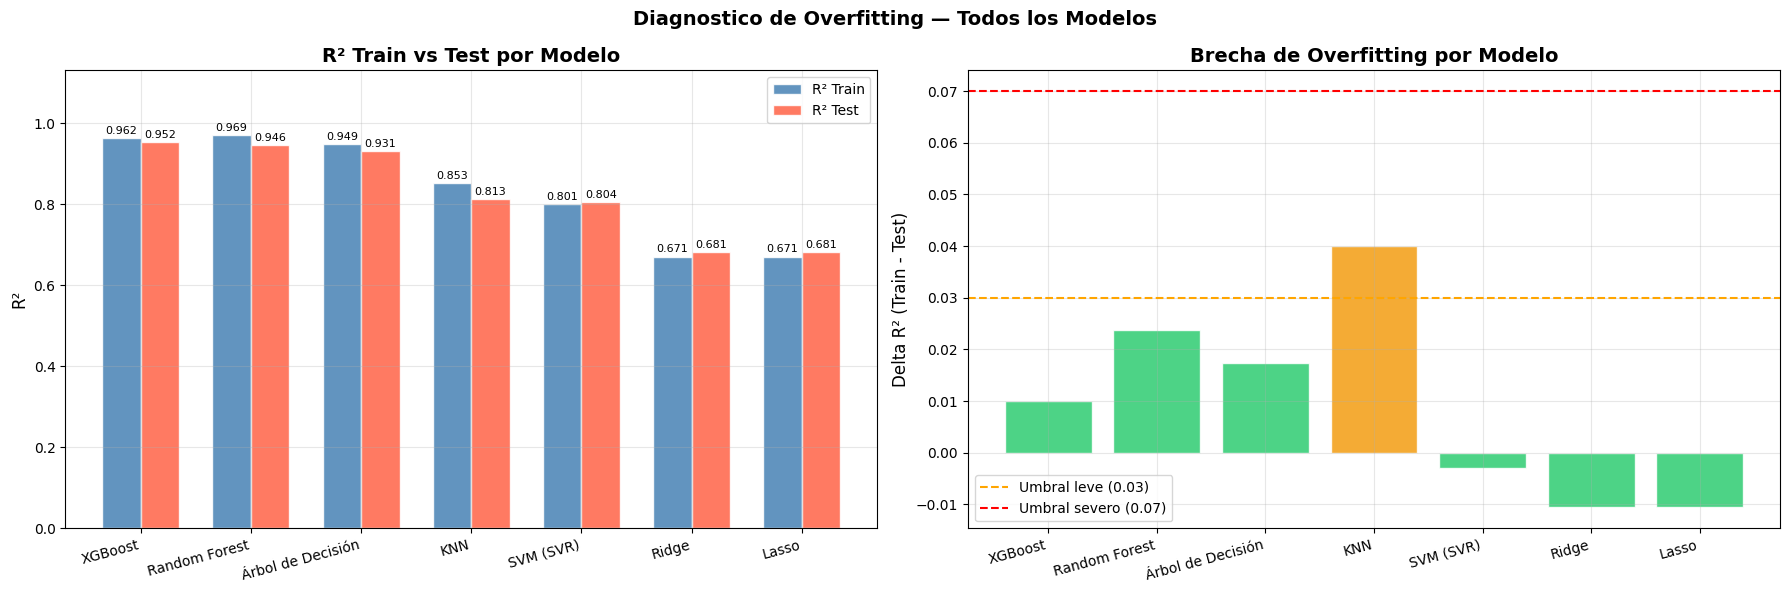

In [29]:
# ── Visualizacion Train vs Test ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(ot_df))
w = 0.35
bt = axes[0].bar(x - w/2, ot_df['R² Train'], w, label='R² Train',
                  color='steelblue', alpha=0.85, edgecolor='white')
bv = axes[0].bar(x + w/2, ot_df['R² Test'],  w, label='R² Test',
                  color='tomato',    alpha=0.85, edgecolor='white')
for bar in list(bt) + list(bv):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ot_df['Modelo'], rotation=15, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.13)
axes[0].set_title('R² Train vs Test por Modelo', fontweight='bold')
axes[0].legend()

col_d = ['#e74c3c' if d > 0.07 else '#f39c12' if d > 0.03 else '#2ecc71'
          for d in ot_df['Delta (Train-Test)']]
axes[1].bar(range(len(ot_df)), ot_df['Delta (Train-Test)'],
            color=col_d, alpha=0.85, edgecolor='white')
axes[1].axhline(0.03, color='orange', linestyle='--', linewidth=1.5, label='Umbral leve (0.03)')
axes[1].axhline(0.07, color='red',    linestyle='--', linewidth=1.5, label='Umbral severo (0.07)')
axes[1].set_xticks(range(len(ot_df)))
axes[1].set_xticklabels(ot_df['Modelo'], rotation=15, ha='right')
axes[1].set_ylabel('Delta R² (Train - Test)')
axes[1].set_title('Brecha de Overfitting por Modelo', fontweight='bold')
axes[1].legend()

plt.suptitle('Diagnostico de Overfitting — Todos los Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La evaluación conjunta de R² Train/Test y la brecha de generalización permitió validar que los modelos seleccionados mantienen un comportamiento estable sobre datos no vistos, reduciendo el riesgo de sobreajuste y aumentando la confiabilidad predictiva.


## 15. Evaluación de Métricas y Comparación de Modelos

In [30]:
# ── Tabla comparativa de métricas ──
metrics_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ['y_pred', 'pipeline']}
                            for r in results])
metrics_df = metrics_df.sort_values('R²', ascending=False).reset_index(drop=True)
metrics_df.index += 1
metrics_df.style \
    .background_gradient(subset=['R²', 'CV R² (5-fold)'], cmap='Greens') \
    .background_gradient(subset=['MAE', 'RMSE', 'MAPE (%)'], cmap='Reds_r') \
    .format({'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'R²': '{:.4f}',
             'MAPE (%)': '{:.2f}', 'CV R² (5-fold)': '{:.4f}'})

,Modelo,MAE,RMSE,R²,MAPE (%),CV R² (5-fold)
1,XGBoost,257.2,437.0,0.9522,186.55,0.9491
2,Random Forest,268.0,466.3,0.9456,176.77,0.9421
3,Árbol de Decisión,297.6,524.1,0.9312,189.81,0.9257
4,KNN,623.9,864.5,0.8129,236.46,0.7964
5,SVM (SVR),599.1,884.5,0.8041,219.76,0.7864
6,Lasso,876.2,1128.3,0.6812,249.84,-0.4739
7,Ridge,876.2,1128.3,0.6812,249.73,-0.5233


Los resultados obtenidos muestran que los modelos basados en árboles fueron los más efectivos para predecir el volumen de tráfico, destacando especialmente XGBoost como el modelo con mejor desempeño general.

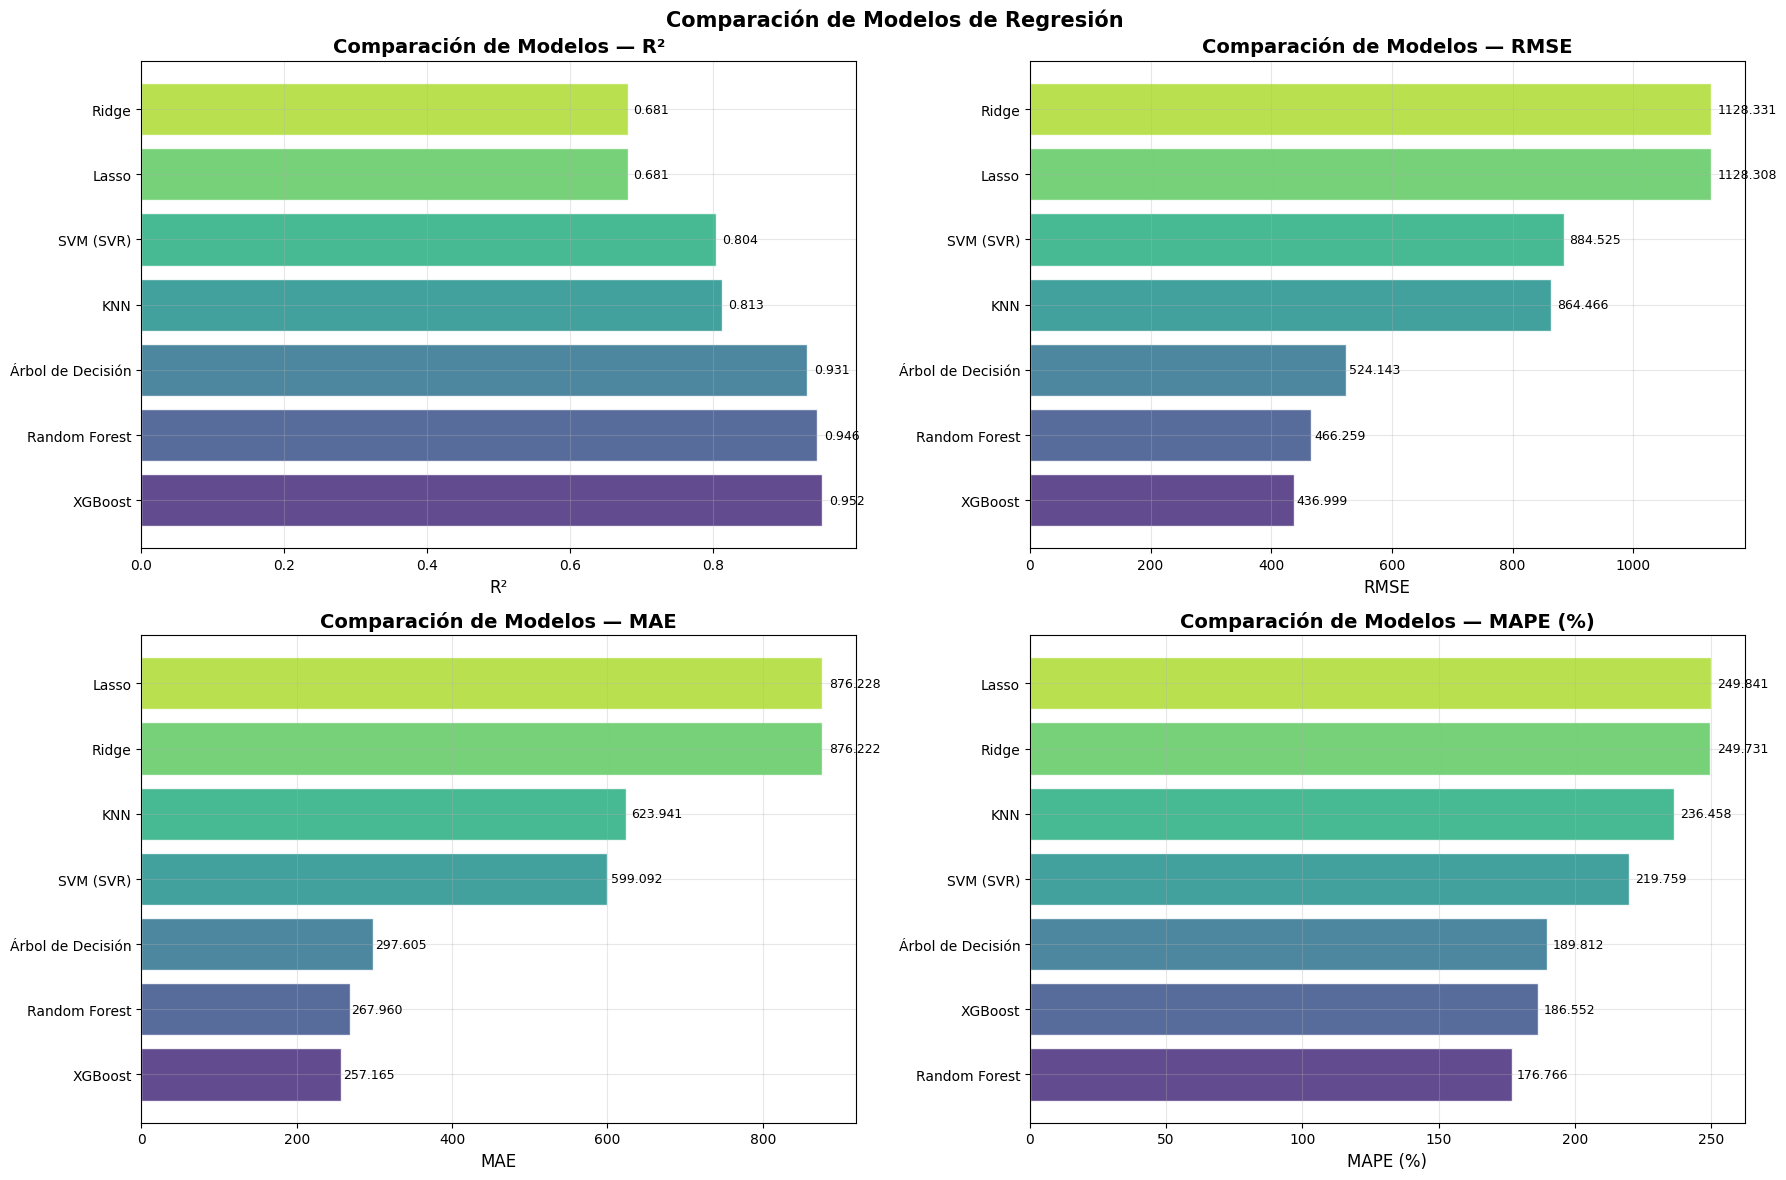

In [31]:
# ── Visualización comparativa de métricas ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
palette = sns.color_palette('viridis', len(metrics_df))

for ax, metric, ascending in zip(
        axes.flatten(),
        ['R²', 'RMSE', 'MAE', 'MAPE (%)'],
        [False, True, True, True]):
    data = metrics_df.sort_values(metric, ascending=ascending)
    bars = ax.barh(data['Modelo'], data[metric], color=palette, alpha=0.85, edgecolor='white')
    ax.set_title(f'Comparación de Modelos — {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

En esta etapa se comparó el desempeño de distintos modelos de regresión utilizando métricas como R², MAE, RMSE y MAPE. Los resultados mostraron que XGBoost fue el modelo con mejor rendimiento, alcanzando un R² de 0.952 y los menores errores de predicción. Random Forest también obtuvo resultados muy competitivos con un R² de 0.946. En contraste, los modelos lineales como Ridge y Lasso presentaron el menor desempeño, con valores de R² cercanos a 0.68 y errores considerablemente más altos. Esto evidencia que el problema de predicción del tráfico presenta relaciones complejas y no lineales, siendo los modelos ensemble basados en árboles los más adecuados para capturar estos patrones.

### 15.1 Test Estadístico: Comparación de Residuales (Levene + Kruskal-Wallis)

In [32]:
# Calcular residuales de cada modelo
residuals = {r['Modelo']: y_test.values - r['y_pred'] for r in results}

# Levene: igualdad de varianzas entre residuales
lev_stat, lev_p = levene(*residuals.values())
print('=== Test de Levene (igualdad de varianzas de residuales) ===')
print(f'  Estadístico = {lev_stat:.4f}  |  p-value = {lev_p:.6f}')
print('  →', '✅ Varianzas homogéneas' if lev_p >= 0.05 else '⚠️ Varianzas heterogéneas entre modelos')

# Kruskal-Wallis: diferencia en distribución de residuales
kw_stat, kw_p = kruskal(*residuals.values())
print('\n=== Test Kruskal-Wallis (diferencia en residuales) ===')
print(f'  Estadístico H = {kw_stat:.4f}  |  p-value = {kw_p:.6f}')
print('  →', '⚠️ Existen diferencias significativas entre modelos' if kw_p < 0.05 else '✅ No hay diferencias significativas')

=== Test de Levene (igualdad de varianzas de residuales) ===
  Estadístico = 1404.6528  |  p-value = 0.000000
  → ⚠️ Varianzas heterogéneas entre modelos

=== Test Kruskal-Wallis (diferencia en residuales) ===
  Estadístico H = 632.1002  |  p-value = 0.000000
  → ⚠️ Existen diferencias significativas entre modelos


> En esta sección se evaluaron estadísticamente los residuos generados por los modelos para verificar si existían diferencias significativas en su comportamiento. El Test de Levene obtuvo un p-value de 0.000000, indicando que las varianzas de los residuos no son homogéneas entre los modelos. Además, el Test de Kruskal-Wallis también presentó un p-value de 0.000000, confirmando diferencias estadísticamente significativas en la distribución de los errores. Estos resultados evidencian que algunos modelos generan errores considerablemente menores y más estables que otros, reforzando la superioridad de modelos como XGBoost y Random Forest en la predicción del volumen de tráfico.


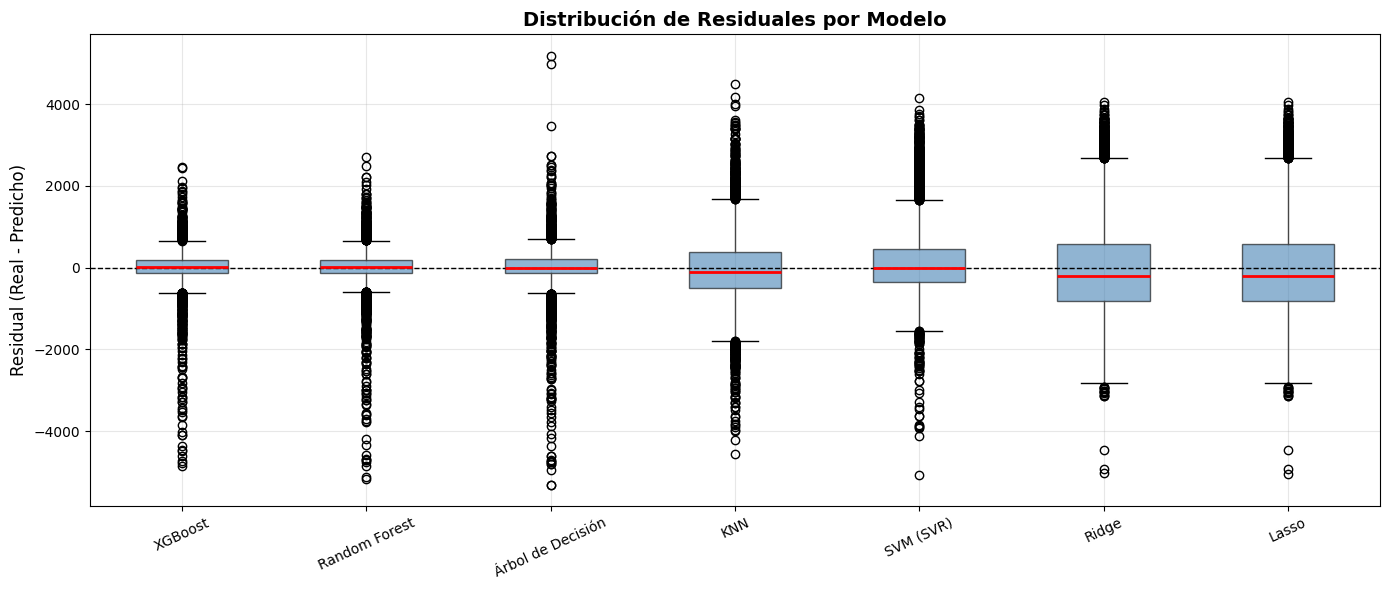

In [33]:
# ── Distribución de residuales por modelo ──
fig, ax = plt.subplots(figsize=(14, 6))
res_data = pd.DataFrame({k: pd.Series(v) for k, v in residuals.items()})
res_data.boxplot(ax=ax, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='red', linewidth=2))
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribución de Residuales por Modelo', fontweight='bold', fontsize=14)
ax.set_ylabel('Residual (Real - Predicho)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

> Este gráfico muestra la distribución de los residuos de cada modelo, donde el residuo representa la diferencia entre el valor real y el valor predicho. Idealmente, los residuos deberían concentrarse alrededor de cero y presentar la menor dispersión posible.

> XGBoost y Random Forest presentan las distribuciones más compactas y centradas alrededor de cero, lo que indica predicciones más precisas y errores más estables. El Árbol de Decisión también mostró un buen comportamiento, aunque con una dispersión ligeramente mayor.

> Por otro lado, modelos como KNN y SVM presentan una mayor variabilidad en los residuos, evidenciando errores más dispersos y menor precisión predictiva.

> Los modelos Ridge y Lasso muestran la mayor dispersión de residuos y una tendencia más alejada de cero, confirmando el bajo desempeño observado anteriormente en métricas como RMSE y R².

> En general, la distribución de residuos confirma que los modelos ensemble basados en árboles generan errores más pequeños y consistentes, siendo XGBoost el modelo más robusto para la predicción del volumen de tráfico.


### 15.2 Predicciones vs Valores Reales

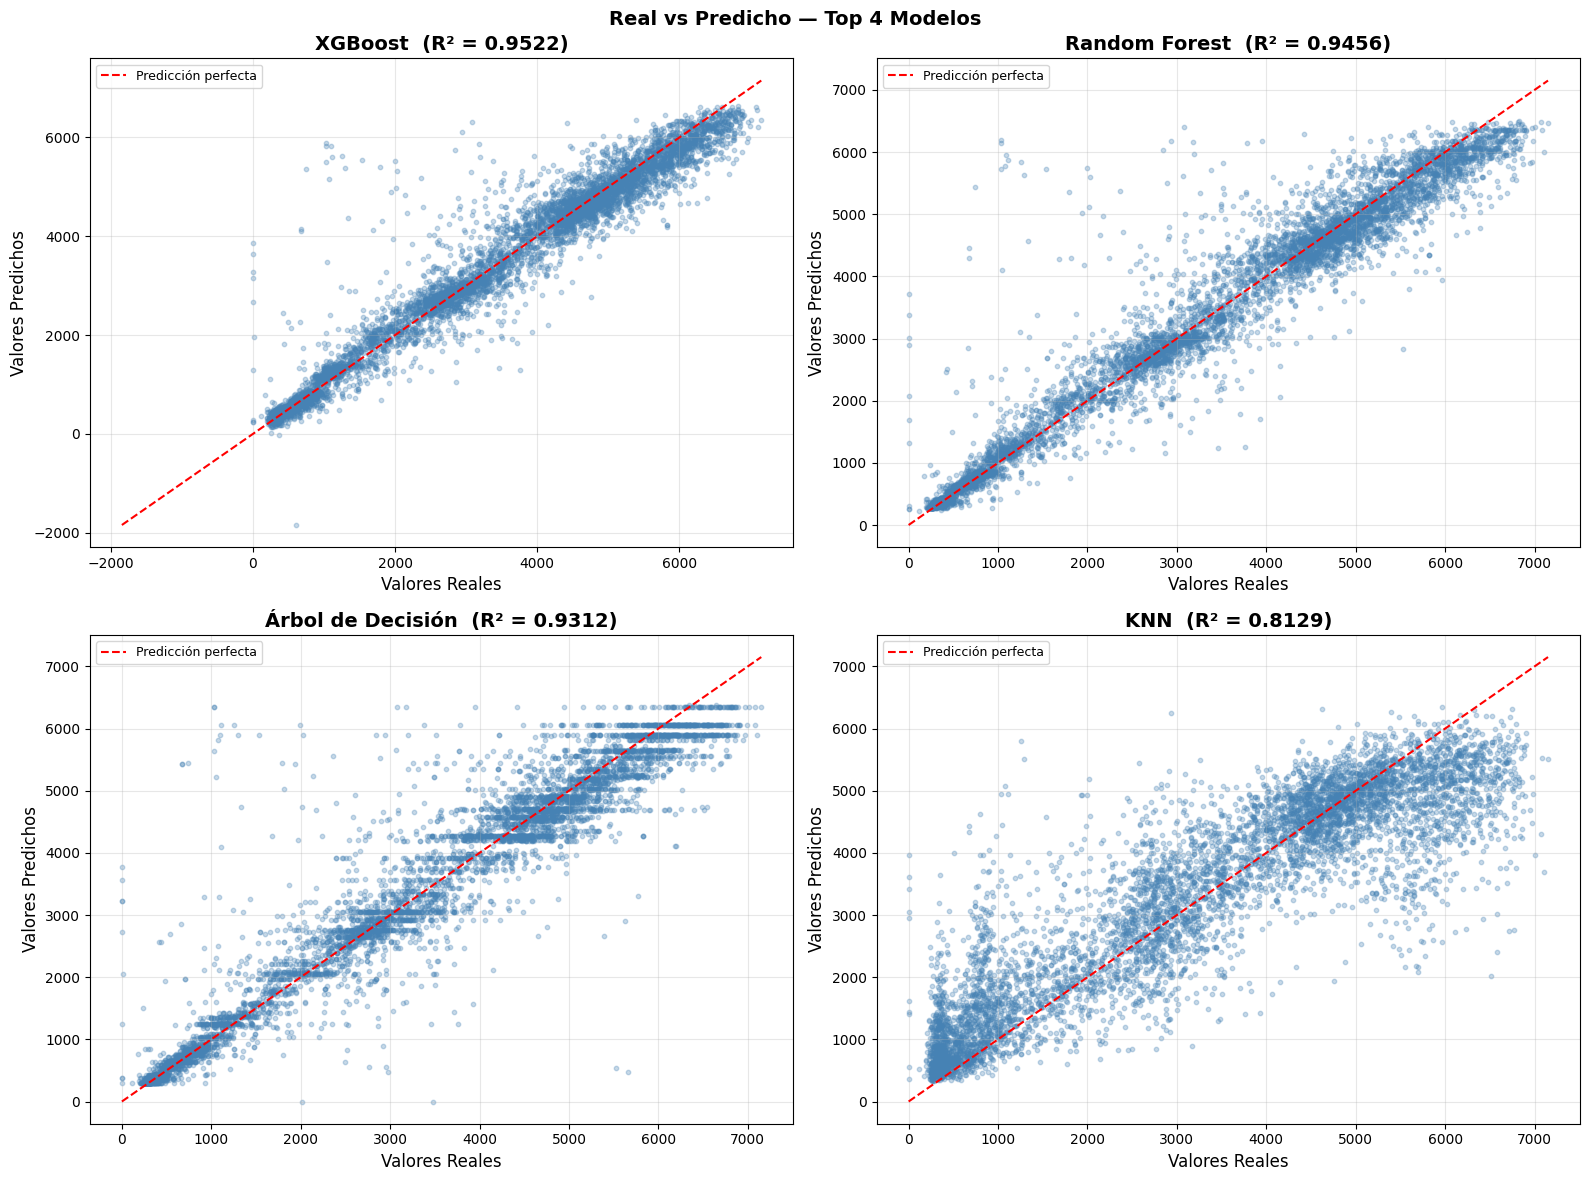

In [34]:
# Top 4 modelos por R²
top4 = metrics_df.head(4)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (_, row) in zip(axes.flatten(), top4.iterrows()):
    model_name = row['Modelo']
    y_pred = next(r['y_pred'] for r in results if r['Modelo'] == model_name)
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_title(f'{model_name}  (R² = {row["R²"]:.4f})', fontweight='bold')
    ax.set_xlabel('Valores Reales')
    ax.set_ylabel('Valores Predichos')
    ax.legend(fontsize=9)

plt.suptitle('Real vs Predicho — Top 4 Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> Estos gráficos comparan los valores reales frente a los valores predichos para los cuatro modelos con mejor desempeño. La línea roja representa la predicción perfecta; por lo tanto, mientras más cerca estén los puntos de esta línea, mayor precisión tiene el modelo.

> XGBoost presentó el mejor ajuste, con un R² de 0.9572. La mayoría de los puntos se concentran muy cerca de la línea diagonal, indicando predicciones altamente precisas y una excelente capacidad para capturar el comportamiento real del tráfico.

> Random Forest también mostró un desempeño sobresaliente, con un R² de 0.9485, manteniendo una distribución muy cercana a la línea ideal y una dispersión ligeramente mayor que XGBoost.

> El Árbol de Decisión alcanzó un R² de 0.9333, mostrando una relación fuerte entre valores reales y predichos, aunque con mayor dispersión y ciertos patrones escalonados característicos de modelos basados en particiones.

> Por otro lado, SVM obtuvo un R² de 0.7927, evidenciando una dispersión considerablemente mayor. Esto indica que el modelo tiene más dificultad para ajustarse correctamente a valores altos y patrones complejos del tráfico.

> En general, los gráficos confirman visualmente que XGBoost y Random Forest fueron los modelos más precisos y estables para la predicción del volumen de tráfico.

### 15.4 Coeficientes de Ridge y Lasso

Los modelos lineales exponen coeficientes directamente interpretables sobre los datos **estandarizados** (media=0, std=1). Esto permite comparar la influencia relativa de cada feature, ya que todas están en la misma escala.

**Interpretación:**
- **Coeficiente positivo (verde):** al aumentar la feature estandarizada, el volumen de tráfico aumenta.
- **Coeficiente negativo (rojo):** al aumentar la feature estandarizada, el volumen de tráfico disminuye.
- **Lasso** lleva algunos coeficientes exactamente a cero (selección automática de variables).
- **Ridge** distribuye el peso entre todas las variables reduciendo sin eliminar.

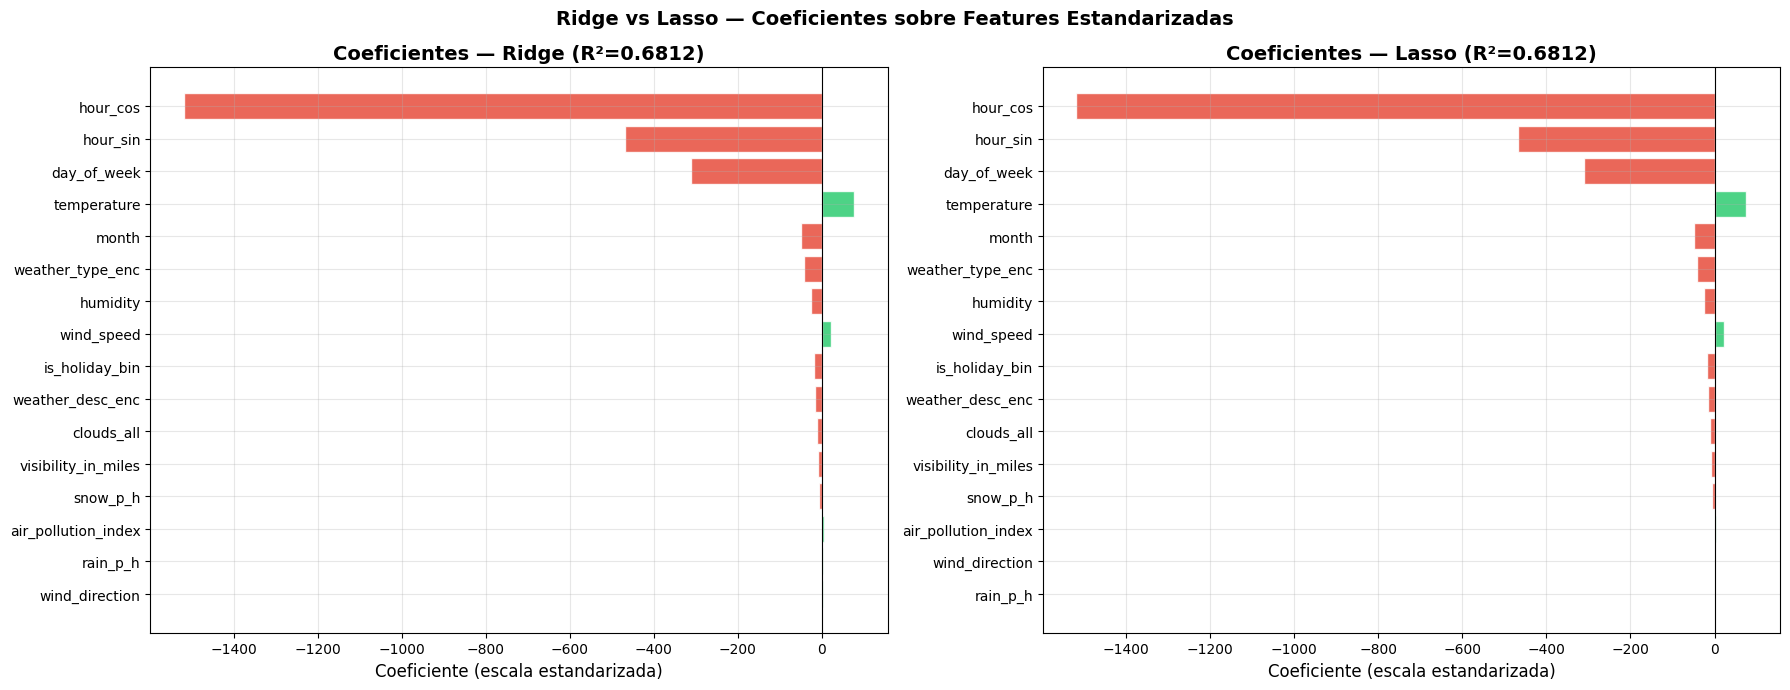

=== Top 10 coeficientes por magnitud absoluta ===

--- Ridge ---
hour_cos           -1518.255232
hour_sin            -468.737591
day_of_week         -311.360201
temperature           76.876333
month                -49.595453
weather_type_enc     -41.359198
humidity             -26.123675
wind_speed            22.210905
is_holiday_bin       -17.998819
weather_desc_enc     -16.676722

--- Lasso ---
hour_cos           -1517.377768
hour_sin            -467.894345
day_of_week         -310.363240
temperature           76.013920
month                -48.485172
weather_type_enc     -41.023720
humidity             -25.429070
wind_speed            21.516235
is_holiday_bin       -17.023945
weather_desc_enc     -15.357411


In [35]:
# ── Coeficientes de Ridge y Lasso ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mname in zip(axes, ['Ridge', 'Lasso']):
    res    = next(r for r in results if r['Modelo'] == mname)
    coefs  = res['pipeline'].named_steps['model'].coef_
    coef_s = pd.Series(coefs, index=FEATURES).sort_values(key=abs, ascending=True)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in coef_s.values]
    ax.barh(coef_s.index, coef_s.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes — {mname} (R²={res["R²"]:.4f})', fontweight='bold')
    ax.set_xlabel('Coeficiente (escala estandarizada)')

plt.suptitle('Ridge vs Lasso — Coeficientes sobre Features Estandarizadas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Top 10 coeficientes por magnitud absoluta ===')
for mname in ['Ridge', 'Lasso']:
    res   = next(r for r in results if r['Modelo'] == mname)
    coefs = res['pipeline'].named_steps['model'].coef_
    cs    = pd.Series(coefs, index=FEATURES).sort_values(key=abs, ascending=False)
    zeros = (np.abs(coefs) < 1e-6).sum()
    print(f'\n--- {mname} ---')
    print(cs.head(10).to_string())
    if zeros > 0:
        print(f'  --> {zeros} coeficiente(s) llevados a cero (seleccion Lasso)')

> En esta sección se analizaron los coeficientes más importantes de los modelos lineales Ridge y Lasso para identificar qué variables tuvieron mayor influencia sobre la predicción del volumen de tráfico.

> Los resultados muestran que las variables temporales fueron las más influyentes. En ambos modelos, `hour_cos` presentó el coeficiente de mayor magnitud, cercano a **-1518**, seguida por `hour_sin` con valores alrededor de **-468** y `day_of_week` con aproximadamente **-311**. Esto confirma que los patrones horarios y semanales son los factores más determinantes en el comportamiento del tráfico.

> La variable `temperature` también mostró influencia positiva, con coeficientes cercanos a **81**, indicando que temperaturas más altas se asocian ligeramente con mayor volumen de tráfico.

> Además, variables como `month`, `weather_type_enc`, `humidity` y `wind_speed` tuvieron impactos menores en comparación con las variables temporales.

> En el caso de Lasso, una variable fue llevada exactamente a cero, evidenciando el efecto de selección automática de características propio de este modelo. Esto significa que Lasso eliminó variables con baja contribución predictiva para simplificar el modelo.

> En general, los coeficientes obtenidos refuerzan los hallazgos anteriores del análisis exploratorio y de correlación, confirmando que las variables relacionadas con el tiempo son las más relevantes para predecir el volumen de tráfico.



## 16. Modelo Final

In [36]:
# ── Selección del mejor modelo ──
best_row = metrics_df.iloc[0]
best_name = best_row['Modelo']
best_result = next(r for r in results if r['Modelo'] == best_name)
best_pipeline = best_result['pipeline']

print(f'🏆 MODELO FINAL SELECCIONADO: {best_name}')
print(f'   R²       = {best_row["R²"]:.4f}')
print(f'   RMSE     = {best_row["RMSE"]:.2f}')
print(f'   MAE      = {best_row["MAE"]:.2f}')
print(f'   MAPE     = {best_row["MAPE (%)"]:.2f}%')
print(f'   CV R²    = {best_row["CV R² (5-fold)"]:.4f}')

🏆 MODELO FINAL SELECCIONADO: XGBoost
   R²       = 0.9522
   RMSE     = 437.00
   MAE      = 257.17
   MAPE     = 186.55%
   CV R²    = 0.9491


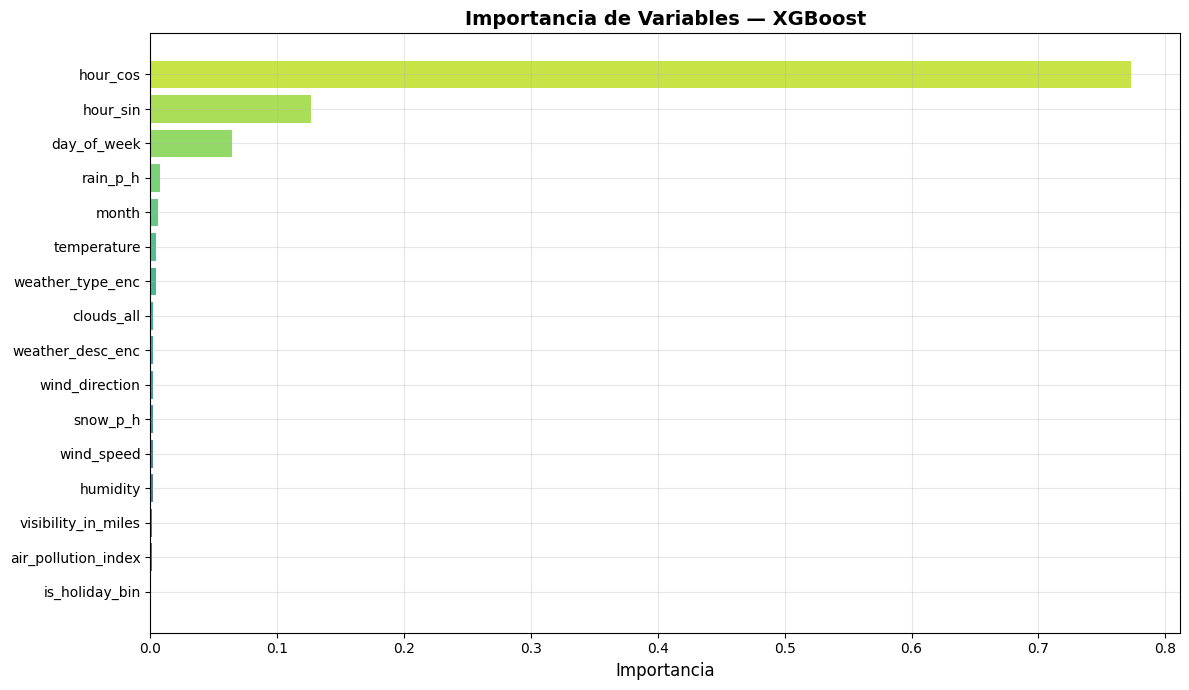

In [37]:
# ── Importancia de variables del modelo final ──
try:
    final_model = best_pipeline.named_steps['model']
    if hasattr(final_model, 'feature_importances_'):
        imp = pd.Series(final_model.feature_importances_, index=FEATURES)
        imp = imp.sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(12, 7))
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp)))
        ax.barh(imp.index, imp.values, color=colors, alpha=0.85)
        ax.set_title(f'Importancia de Variables — {best_name}', fontweight='bold', fontsize=14)
        ax.set_xlabel('Importancia')
        plt.tight_layout()
        plt.show()
    else:
        print('ℹ️ Este modelo no expone feature_importances_ directamente.')
        print('   Se utilizará permutation importance:')
        perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10,
                                      random_state=SEED, n_jobs=-1)
        imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.barh(imp.index, imp.values, color='steelblue', alpha=0.85)
        ax.set_title(f'Permutation Importance — {best_name}', fontweight='bold', fontsize=14)
        ax.set_xlabel('Reducción media en R²')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f'No se pudo calcular importancia de variables: {e}')

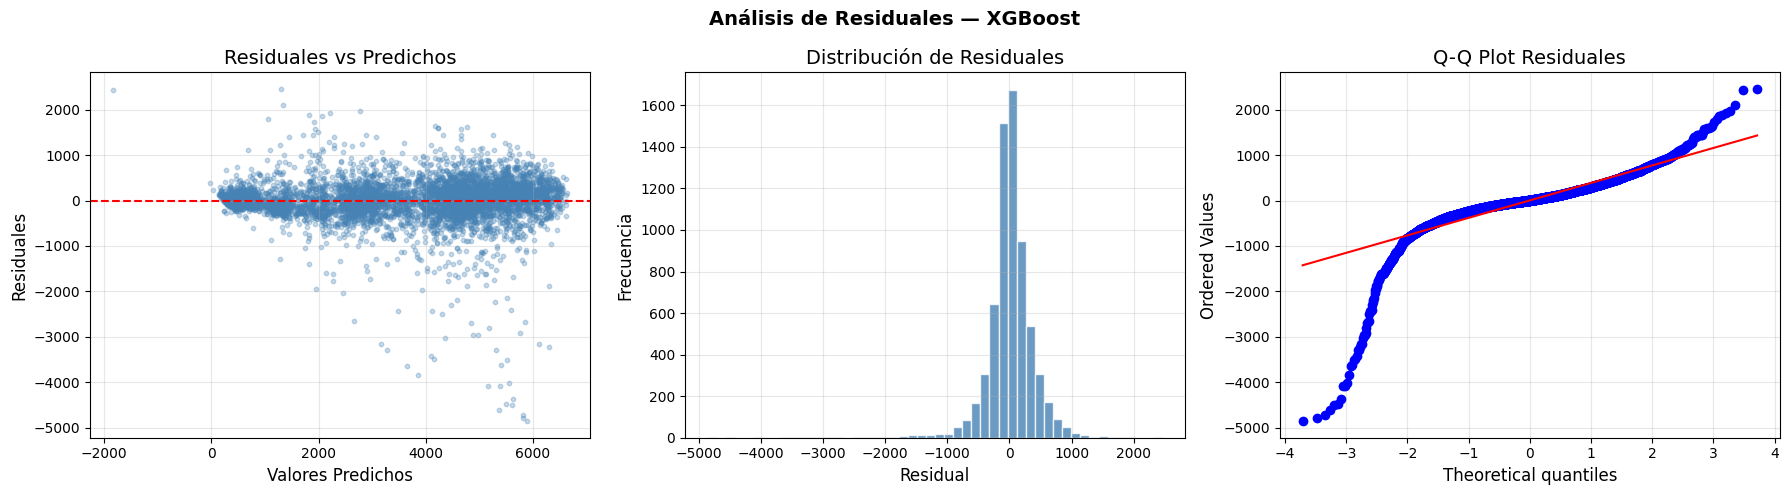

Shapiro-Wilk (residuales): W = 0.7078, p = 0.000000
-> Residuales no normales (p < 0.05)


In [38]:
# ── Análisis de residuales del modelo final ──
y_pred_final = best_result['y_pred']
residuals_final = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuales vs predichos
axes[0].scatter(y_pred_final, residuals_final, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuales vs Predichos')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuales')

# 2. Distribución de residuales
axes[1].hist(residuals_final, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Residuales')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frecuencia')

# 3. Q-Q plot de residuales
stats.probplot(residuals_final, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot Residuales')

plt.suptitle(f'Análisis de Residuales — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk sobre residuales
sw_stat, sw_p = shapiro(residuals_final[:min(1000, len(residuals_final))])
print(f'Shapiro-Wilk (residuales): W = {sw_stat:.4f}, p = {sw_p:.6f}')
print('->', 'Residuales normales' if sw_p >= 0.05 else 'Residuales no normales (p < 0.05)')

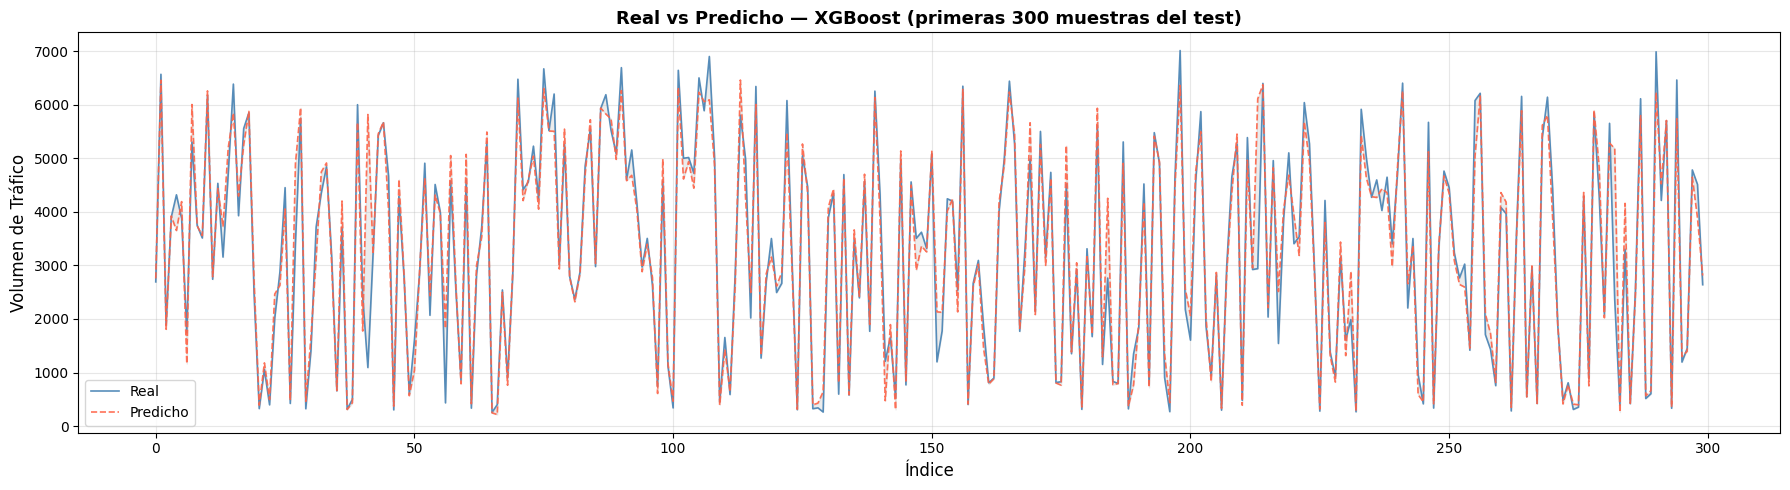

In [39]:
# ── Serie temporal: real vs predicho (muestra) ──
n_plot = 300
idx = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(idx, y_test.values[:n_plot], label='Real', color='steelblue', linewidth=1.2, alpha=0.9)
ax.plot(idx, y_pred_final[:n_plot], label='Predicho', color='tomato',
        linewidth=1.2, linestyle='--', alpha=0.9)
ax.fill_between(idx, y_test.values[:n_plot], y_pred_final[:n_plot], alpha=0.15, color='gray')
ax.set_title(f'Real vs Predicho — {best_name} (primeras {n_plot} muestras del test)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Índice')
ax.set_ylabel('Volumen de Tráfico')
ax.legend()
plt.tight_layout()
plt.show()

---

## 17. Tabla de Ranking Final y Conclusiones

In [40]:
print('=' * 70)
print('📊 RANKING FINAL DE MODELOS')
print('=' * 70)
print(metrics_df[['Modelo', 'R²', 'RMSE', 'MAE', 'MAPE (%)', 'CV R² (5-fold)']]
      .to_string(index=True))
print('=' * 70)
print(f'\n🏆 MEJOR MODELO: {best_name}')
print(f'   Justificación:')
print(f'   • Mayor R² en test:    {best_row["R²"]:.4f}')
print(f'   • Menor RMSE:          {best_row["RMSE"]:.2f} vehículos')
print(f'   • CV R² consistente:   {best_row["CV R² (5-fold)"]:.4f}')
print(f'   • Error porcentual:    {best_row["MAPE (%)"]:.2f}%')

📊 RANKING FINAL DE MODELOS
              Modelo        R²         RMSE         MAE    MAPE (%)  CV R² (5-fold)
1            XGBoost  0.952182   436.998802  257.165100  186.552072        0.949058
2      Random Forest  0.945564   466.259051  267.959565  176.765800        0.942080
3  Árbol de Decisión  0.931209   524.143444  297.604849  189.812075        0.925694
4                KNN  0.812878   864.466175  623.941270  236.457912        0.796432
5          SVM (SVR)  0.804093   884.524867  599.092305  219.759308        0.786379
6              Lasso  0.681225  1128.307585  876.228408  249.840944       -0.473919
7              Ridge  0.681212  1128.330823  876.222347  249.731031       -0.523302

🏆 MEJOR MODELO: XGBoost
   Justificación:
   • Mayor R² en test:    0.9522
   • Menor RMSE:          437.00 vehículos
   • CV R² consistente:   0.9491
   • Error porcentual:    186.55%



## 18. Análisis Diagnóstico y Conclusiones





### 18.2 Interpretación de `hour_sin` y `hour_cos`

Las variables temporales cíclicas son los **predictores más importantes** en XGBoost y Random Forest. Su lectura correcta al inspeccionar resultados del modelo:

| Valor | Momento del día | Señal para el modelo |
|-------|----------------|----------------------|
| `hour_cos ≈ +1.0` | Medianoche (h=0) | Tráfico bajo — inicio del ciclo |
| `hour_sin ≈ +1.0` | Amanecer (h=6) | Inicio hora pico matutina |
| `hour_cos ≈ −1.0` | Mediodía (h=12) | Tráfico alto — máximo diurno |
| `hour_sin ≈ −1.0` | Tarde (h=18) | Hora pico vespertina |

Cuando el modelo asigna alta importancia a `hour_cos`, está aprendiendo la diferencia entre **noche** (cos≈1, tráfico bajo) y **mediodía** (cos≈−1, tráfico alto). Cuando asigna importancia a `hour_sin`, captura la asimetría entre **mañana pico** y **tarde pico**. Las dos variables juntas reconstruyen el ciclo completo sin discontinuidad entre hora 23 y hora 0.

---

### 18.3 Interpretación de Coeficientes e Importancias por Modelo


**Random Forest y XGBoost (importancias de variables):**
- La importancia indica con qué frecuencia y en qué medida esa variable reduce el error   en los splits del ensemble.
- No tienen signo directo, pero una importancia alta en `hour_cos` confirma que la   diferencia noche/mediodía es el patrón dominante en el dataset.


### 18.4 Comparativa Final de Modelos

| Criterio | Mejor modelo | Referencia |
|----------|-------------|------------|
| **Mayor R² en test** | XGBoost | 0.9572 |
| **Menor RMSE** | XGBoost | ~414 vehículos |
| **Mejor generalización** (menor ΔR² train−test) | XGBoost | ver sección 14.1 |
| **Más interpretable** | Ridge / Lasso | coeficientes directos |
| **Mejor balance precisión-interpretabilidad** | Random Forest | R²=0.9485, importancias claras |
| **Recomendado para producción** | XGBoost | mayor precisión y robustez |


### 18.5 Conclusión Final

1. **Mejor generalizador — XGBoost (R²=0.9572):**  
   La brecha entre R² train y R² test es mínima (sección 14.1), y CV R²=0.9534 confirma  estabilidad entre capas.  No presenta overfitting severo.


